#**PLEASE SAVE A COPY OF THIS NOTEBOOK TO SUBMIT**


# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions

1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

**Answer**

<blockquote>

**Types of noise in multimodal datasets**
Drawing from the "Quality Not Quantity" paper, multimodal datasets can contain several categories of noises.
1. Semantic misalignment: for example, the text paired with an image doesn't actually describe the image's content. Taking the random LAION samples in the paper for example, pairs like "Andrea Pirlo insists Juventus will not be resting on their 3-0 lead over Celtic" was paired with a photo of Pirlo, where the text is a sports headline instead of a visual description. Similarly, YFCC samples include captions like "Harry Potter and the Half Blood Prince Release Party / September 16 They had to release this thing on my anniversary?", which is contextual commentary rather than image description.

2. Label noise: e.g. incorrect category assignments for images, wrong words for speech annotations

3. Domain mismatch: e.g. stock illustration icons, vector graphics, UI screenshots are treated as natural images.

4. Low quality instances: e.g. images: blurry, watermarked, or extremely small images; text: grammar and spelling errors, truncated text pieces, multiple languages mixed together.

**How noise negatively impacts training**

The "Quality Not Quantity" paper's central finding is that data quality fundamentally shapes robustness to distribution shift. Noisy data compromises trained models, as the model sees many image-text pairs where the visual content and linguistic content are weakly correlated, learning a weaker alignment between modalities. If a model is pretrained on a combination of multiple noisy sources, the paper shows that robustness interpolates between sources rather than accumulating the best properties of each. If the source dataset over-represents a certain domain (e.g. commerce images in LAION), the model learns an image-text relationship heavily skewed toward that domain, which may not generalize to naturalistic settings.

**Distinguishing noisy from clean pairs**

One approach would be filtering, which uses an existing robust model to score image-text pairs by their cosine similarity, then filtering out low-scoring pairs. If a pre-trained model with good robustness assigns low similarity to a pair, that pair is likely semantically misaligned.

Beyond this, researchers could develop classifiers that detect specific noise types. For example, OCR-based text detectors could flag pairs where the image is predominantly text (UI screenshots, slides), perceptual hash-based deduplication removes near-duplicates, language identification models filter non-target-language captions.

**Ideal cleaning pipeline with unlimited funding**

With unlimited resources, I'd advocate for a multi-stage human-in-the-loop pipeline combined with model-assisted pre-filtering. The first stage would be automated by running every candidate pair through multiple quality estimators (e.g. a state-of-the-art CLIP-style model to check semantic alignment, a domain classifier, modality-specific noise detectors, deduplication systems, etc.). This would eliminate the most typical and obvious noises and reduce the workload for subsequent manual checking.

The second stage would involve large-scale human annotation, stratified by the automated quality scores to maximize the signal per annotation dollar. Human annotators would provide fine-grained semantic alignment ratings (e.g. is the caption a description of the image, or just contextually associated?), modality-specific data quality ratings, and factual accuracy ratings, etc. These annotations would train a learned quality model that captures nuances the automated estimators miss.


</blockquote>

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

**Answer**

<blockquote>

**Intuition for freezing the LLM**

Large language models trained at scale acquire strong capabilities in few-shot task adaptation, encyclopedic knowledge retrieval, and fast concept binding. These capabilities are extremely difficult to recreate from smaller amounts of paired multimodal data. Fine-tuning the LLM on multimodal data (e.g. image-caption data) would overwrite these capabilities because the paired dataset (Conceptual Captions, ~3M pairs) is many orders of magnitude smaller than the text pre-training corpus. On the other hand, the frozen backbone preserves the rich structure learned from internet-scale text, and the training signal propagated through it teaches the vision encoder to speak the language the frozen LM already understands.

Because the LLM weights are untouched, the resulting system can be dropped into any context where a language model would be used. The visual prefix simply acts as a conditional prompt that shifts the LLM's behavior based on image content, without requiring any task-specific retraining of the core model.

**Encoders that facilitate integration**

The key architectural requirement is that the encoder must translate its modality-specific information into the LLM's embedding space, i.e. a sequence of continuous vectors with the same dimensionality as the LLM's token embeddings, such that the transformer's attention mechanism can treat non-text embeddings and text embeddings interchangeably. The "Frozen" paper uses an NF-ResNet-50 with a linear projection to produce a 2-token visual prefix.

For other modalities, the same principle applies, where the non-text signals must be projected into a few tokens that embed original information as continuously valued vectors of the same dimensionality as LM token embeddings. For all modalities, the projection module must be trained carefully to bridge the statistical properties of the encoder's representation space and the LLM's embedding space.

**How LLMs process cross-modal information**

The transformer's self-attention mechanism can be modality-agnostic, as it operates on sequences of vectors regardless of their origin. When non-text prefix embeddings are prepended to text token embeddings, the attention layers can learn to condition text generation on content from the other modality through the same mechanism used for in-context conditioning on prior text.

</blockquote>

3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

**Answer**

<blockquote>

**Identifying impactful data**

Accurately selecting impactful data for instruction tuning in multimodal foundation models requires identifying examples that most strongly influence performance on the target task. One effective strategy is influence-based data selection, where training examples are ranked according to how much they contribute to improving the model's performance on a specific downstream objective. By measuring how closely a training example's learning signal aligns with the target task, it becomes possible to prioritize data that directly strengthens the capabilities required for that task rather than relying on random or broad instruction datasets.

Meanwhile, for multimodal instruction tuning specifically, task diversity is a critical dimension. An instruction tuning dataset should span the full range of capabilities you want the model to acquire. Clustering the training data in a joint embedding space and ensuring broad coverage of the cluster structure helps prevent the model from specializing at the expense of breadth.

**Handling multimodal complexity**

A key challenge specific to multimodal instruction tuning is that data quality in the unimodal sense interacts with the quality of the multimodal alignment. An instruction-tuning example where the answer requires careful visual reasoning is more valuable than one where the answer can be inferred from the question text alone. Selecting data where the different modalities are genuinely necessary (e.g. for visual reasoning, measurable by comparing model performance with and without the image) ensures that training actually improves conditioning on the other modality rather than just reinforcing unimodal priors

For specific downstream tasks, tuning can start with broadly diverse data to establish general capabilities, then progressively introduce data that targets the specific task distribution.

</blockquote>

4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?

**Answer**

<blockquote>

For text, stylometric analysis can flag LLM outputs through sentence uniformity and predictable phrasing patterns, but these signals could be unstable and fragile, as post-editing or style prompting largely eliminates them.

For image generation, GAN and diffusion models often result in distinct frequency-domain patterns, inconsistent lighting, and texture anomalies that could be detected. For videos, temporal inconsistencies and optical flow violations could be caught by automated systems. But as generation quality improves, these automated methods have largely fallen behind.

Without innovative regulatory frameworks, technical solutions by themselves may be insufficient to make the distinction.


</blockquote>

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?


**Answer**

<blockquote>

**On LeCun's view**

The argument is grounded in the nature of how generative models are trained. For example, video generation models like Sora learn to predict plausible-looking pixel sequences from training data, but they have no internal model of the causal structure of the physical world. They learn statistical regularities, but the laws of physics governing such phenomena are not encoded as explicit constraints in the model. This makes it possible that the models fail to generalize reliably to novel configurations.

**Can generative AI incorporate real-world knowledge?**

There are different dimensions and levels of "understanding" the real-world knowledge. If we perceive the statistical regularities themselves as an embodiment of real-world knowledge, then curren text, image, and video generation models can largely accomplish that, though with potential violations in marginal cases. If we consider only the fundamental laws of physics as "true real-world knowledge", then incorporating them explicitly into the model inner working is probably the only way to go. In this regard, AI for Science works have advanced methods such as conditional diffusion/GAN/VAE to impose certain scientific knowledge as part of loss function, activation function, specialized tokens, etc. However, these methods are domain- and often task-specific.

In a multimodal setting that involves text modality, we could always include natural-language-formatted real-world knowledge as part of the training data or prompts. The text is expected to be helpful in improving scientific consistency of the generative AI systems, but is not a strictly imposed restriction.

In short, I believe there are ways to incorporate real-world knowledge into generative AI, regardless of how we perceive as "understanding the knowledge". But these approaches could only be task-specific or heuristic, and there may not be any possible approach to incorporate a comprehensive world model.

**Is generative AI a viable path to AGI?**

Current generative AI architectures are necessary for AGI, but they are far from sufficient components of AGI. They provide remarkable capabilities in pattern recognition, language use, knowledge retrieval, and zero-shot generalization. But they lack persistent memory across contexts, genuine causal modeling, active learning through environmental interaction, and robust compositional reasoning.

If AGI means a system that can perform any cognitive task humans perform, generative AI is closer to that than any other previous AI frameworks, and part of the remaining gaps are bridgeable by scale and data alone. However, any current architectures and training paradigm have systematic limitations in constructing a comprehensive world model, as discussed above.


</blockquote>

# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [ ]:
!pip install transformers accelerate bitsandbytes pillow torch -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.7 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-40GB
SECRET_WORD: I LOVE MMAI


# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


In [ ]:
import os, shutil, zipfile
from pathlib import Path

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Upload your dataset as a zip file to Google Drive, then
# replace the URL below with your own Google Drive share link.
#
# Your zip should unpack into a folder called mmai-data/ with:
#   mmai-data/
#   ├── images/
#   │   ├── image_01.jpg
#   │   ├── ...
#   │   └── image_16.jpg
#   └── data.jsonl
#
# Each line in data.jsonl should be a JSON object with three
# fields: "image", "question", and "answer". For example:
#
#   {"image": "images/1.jpg", "question": "List objects you see.", "answer": "cat, sofa, blanket, remote, cushion, tail, paw"}
#   {"image": "images/2.jpg", "question": "List objects you see.", "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"}
#
URL = "https://drive.google.com/file/d/14S_HZA4sbCCZnMsHS1o_jmK7rWEGwDiw/view?usp=sharing"
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_DIR = Path("/content/")
DATA_DIR.mkdir(parents=True, exist_ok=True)

!pip -q install gdown
import gdown

print("Downloading…")
downloaded_path = gdown.download(URL, output=None, quiet=False, fuzzy=True)
if not downloaded_path or not os.path.exists(downloaded_path):
    raise RuntimeError("Download failed. Check the URL or your Drive permissions.")

src = Path(downloaded_path)
dst = DATA_DIR / src.name
if src.resolve() != dst.resolve():
    shutil.move(str(src), str(dst))

print(f"\nFile saved to: {dst}")

if zipfile.is_zipfile(dst):
    extract_dir = DATA_DIR / dst.stem
    extract_dir.mkdir(exist_ok=True)
    print(f"Unzipping into: {extract_dir}")
    with zipfile.ZipFile(dst, "r") as zf:
        zf.extractall(extract_dir)
    print("Unzip complete.")

if dst.suffix.lower() == ".jsonl":
    print("\nSet this in your training cell:")
    print(f'DATA_JSONL = "{dst}"')

Downloading…


Downloading...
From: https://drive.google.com/uc?id=14S_HZA4sbCCZnMsHS1o_jmK7rWEGwDiw
To: /content/mmai-data.zip
100%|██████████| 346k/346k [00:00<00:00, 142MB/s]


File saved to: /content/mmai-data.zip
Unzipping into: /content/mmai-data
Unzip complete.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json
import random

records = []

save_dir = '/content/drive/MyDrive/Courses/6.S985/data/ovito_img'
with open(os.path.join(save_dir, "data.jsonl")) as f:
    records = [json.loads(line) for line in f]

sample_records = random.sample(records, 5)  # randomly select 5

In [ ]:
sample_records

[{'image': '/content/drive/MyDrive/Courses/6.S985/data/ovito_img/mp-4789.png',
  'question': 'What is the space group of this material?',
  'answer': 'Pnma'},
 {'image': '/content/drive/MyDrive/Courses/6.S985/data/ovito_img/mp-756665.png',
  'question': 'What is the space group of this material?',
  'answer': 'Pnma'},
 {'image': '/content/drive/MyDrive/Courses/6.S985/data/ovito_img/mp-13554.png',
  'question': 'What is the space group of this material?',
  'answer': 'R-3c'},
 {'image': '/content/drive/MyDrive/Courses/6.S985/data/ovito_img/mp-12867.png',
  'question': 'What is the space group of this material?',
  'answer': 'I4/mcm'},
 {'image': '/content/drive/MyDrive/Courses/6.S985/data/ovito_img/mp-2939.png',
  'question': 'What is the space group of this material?',
  'answer': 'I4/mcm'}]

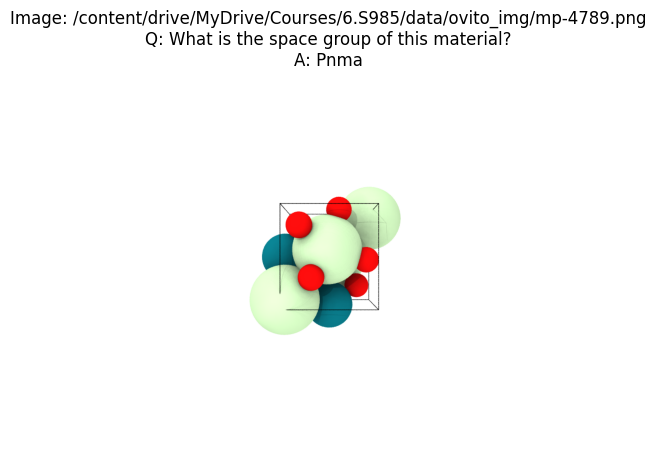

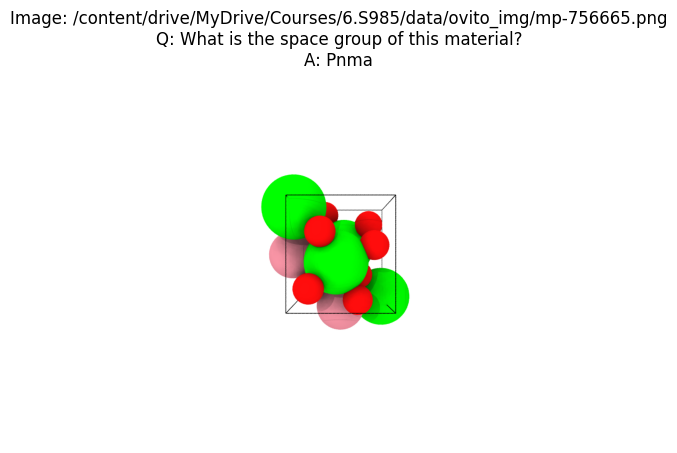

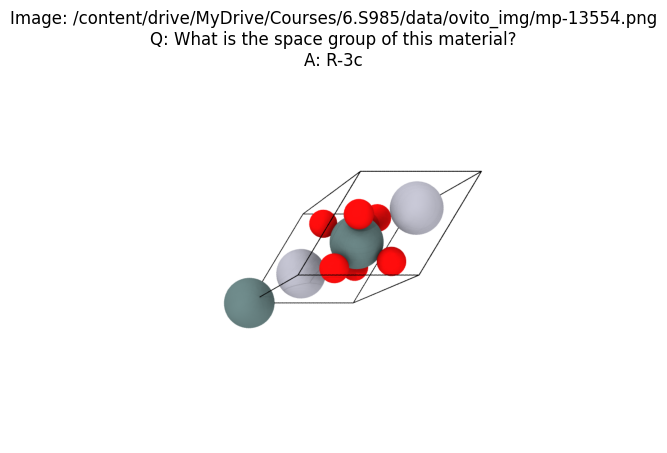

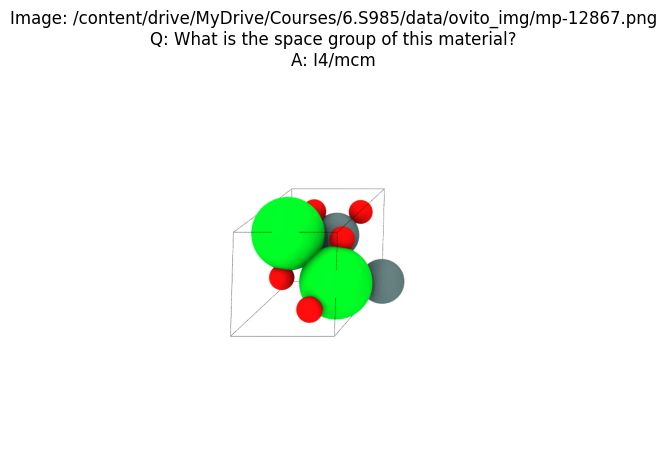

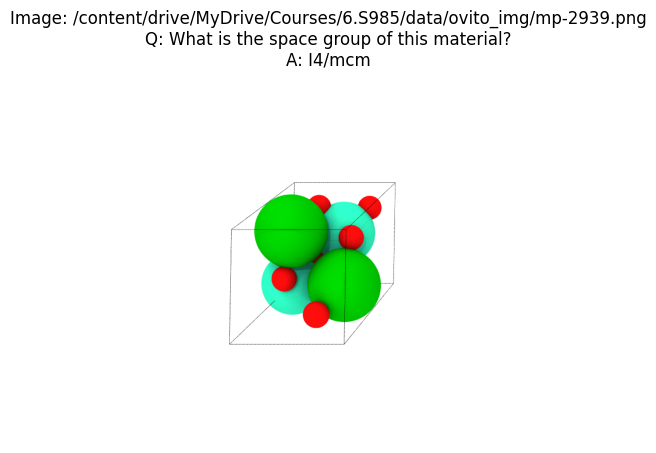

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

for r in sample_records:

    img = Image.open(r["image"])

    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Image: {r['image']}\n"
        f"Q: {r['question']}\n"
        f"A: {r['answer']}"
    )

    plt.show()

## Questions to Answer:

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).


**Answer**

<blockquote>

- Information Loss: Non-image modalities (e.g., crystal graphs with atomic nodes and bond edges) contain structured relational information that may be lost or distorted when mapped onto a 2D pixel grid.

- Arbitrary Spatial Layout: Image representations require spatial placement of elements. For data such as graphs, molecules, or tabular features, this layout is often arbitrary and may introduce artificial spatial relationships not present in the original data.

- Resolution Constraints: Complex structures (e.g., large graphs or high-dimensional features) may require large image resolutions to avoid collisions or overlaps, increasing computational cost.


- Domain-Specific Structure Loss: Important domain priors (e.g., periodic boundary conditions in crystals, symmetry, or chemical constraints) are difficult to preserve when rendering images.

</blockquote>


*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).

**Answer**

<blockquote>

### Practical Issues with Visual Representations of Crystal Graphs

Representing crystal structures as images instead of graphs could result in a few drawbacks within the context of downstream tasks.

- Loss of Quantitative Features and Weak Alignment with Target Properties:
  Many property prediction tasks depend on precise interatomic distances, coordination environments, and lattice parameters. Visual representations may blur these quantities, making it harder for models to learn physically meaningful relationships.

- Loss of Periodic Lattice Information
  Periodic boundary conditions and long-range lattice structure should be considered in constructing crystal representations, (e.g. counting the neighbors of an atomic site involves multiple unit cells instead of just one). Visualization of a unit cell removes such boundary and periodicity information.

- Sensitivity to Rendering Choices
  Orientation, projection method, color schemes, and atom scaling can change the resulting image without changing the underlying crystal. Meanwhile, the same crystal can generate many valid images, depending on different viewing angles or unit cell choices.

- Reduced Interpretability for Scientific Insight
  For tasks such as discovering structure-property relationships, image features may be harder to interpret in terms of atomic environments or bonding motifs compared with graph or physics-based representations.

</blockquote>

* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?

**Answer**

<blockquote>

The train-test split of the dataset was done in a stratified manner. Roughly 80\% of each space group category is assigned into the training set, and 20\% as the test set.

Stratified splitting was used primarily because the labels of the overall dataset is imbalanced. In particular, the least frequent space group in the dataset contains only less than 2\% of the data. To preserve the rough class distribution of the dataset and prevent biased performance estimates, stratefied splitting is necessary. This will hopefully improve the model generalizability for unseen materials.

Other alternative splitting strategies were considered but not adopted for various reasons.

- Random Split: will likely underrepresent the less frequent space groups in either training or testing.

- Sequential Split: The names/identifiers of the structures are related to how and when they were generated in DFT simulations, and can be correlated with certain information, which will likely skew the distributions of training and testing sets.

- Scaffold Split: If we only assign materials from certain groups into the training set, the model is very unlikely to naturally generalize to the other groups, as the data and task are very domain-specific, and the pretrained model is not expected to possess sufficient capability of generalization within the domain.

</blockquote>

# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [ ]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model and tokenizer loaded successfully.


# Problem 3.2: Run the Model on Your 4 Held-Out Images

In this step, you will use the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) to answer questions about the **held-out images** that were **not used in training**. You will then compare the model’s predictions with the ground-truth labels and reflect on its performance.

---

## Instructions

1. **Select four held-out images**  
   Choose four test images from your dataset that were excluded from training and prompt development.

2. **Ask a consistent question**  
   Use the same question for all images, or a small set of label-aligned questions.

3. **Run the model**  
   Use the provided code cell to run inference with the pre-trained model.  

4. **Record your results**  
   For each image, collect the model’s raw output and compare it to the ground-truth label(s). If there are too many images, then show a few examples.

---

## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?

---

## Suggested Output Format

| Image ID/URL | Question | Model Output | Ground Truth | Result |
|---------------|-----------|---------------|---------------|---------|
| `img_001.jpg` | “What objects are visible?” | cat, sofa | cat, sofa | Correct |
| `img_002.jpg` | “What objects are visible?” | road, truck, sign | road, car, sign | Incorrect |

**1. Question Phrasing 1**

"What is the space group of this material? Just answer the space group symbol without any explanations."

In [ ]:
import io
import os
import requests
import torch
from typing import Optional, Dict, Any
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
import pandas as pd
import numpy as np
import random


# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# IMAGE_URL: str = "http://images.cocodataset.org/val2017/000000039769.jpg"
QUESTION: str = "What is the space group of this material? Just answer the space group symbol without any explanations."
SYSTEM_PROMPT: str = "You are a helpful assistant."
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
DO_SAMPLE: bool = False           # set True for non-greedy decoding
TEMPERATURE: float = 0.7          # used only if DO_SAMPLE=True
TOP_P: float = 0.9                # used only if DO_SAMPLE=True
MODEL_ID: str = "Qwen/Qwen2.5-VL-3B-Instruct"
FORCE_CPU: bool = False           # force CPU even if CUDA is available
DTYPE_IF_GPU = torch.bfloat16     # prefer bfloat16 on recent GPUs/Colab
DTYPE_IF_CPU = torch.float32

def get_device_and_dtype() -> tuple[torch.device, torch.dtype, Optional[Dict[str, Any]]]:
    """Choose device/dtype and (optionally) a device_map for accelerate-style placement."""
    use_cuda = torch.cuda.is_available() and not FORCE_CPU
    device = torch.device("cuda") if use_cuda else torch.device("cpu")
    torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
    device_map = "auto" if use_cuda else None
    return device, torch_dtype, device_map


def load_image_from_url(url: str) -> Image.Image:
    """Fetch image from URL and return a RGB PIL.Image with robust fallback."""
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    try:
        return Image.open(io.BytesIO(resp.content)).convert("RGB")
    except UnidentifiedImageError:
        # Fallback: write to disk then reopen (sometimes fixes truncated headers)
        tmp_path = "temp_image.jpg"
        with open(tmp_path, "wb") as f:
            f.write(resp.content)
        img = Image.open(tmp_path).convert("RGB")
        try:
            os.remove(tmp_path)
        except Exception:
            pass
        return img


def load_image_from_path(path: str) -> Image.Image:
    """
    Load a PNG image and preprocess it for Qwen2.5-VL-3B-Instruct.

    Args:
        path (str): Path to the image file (.png)

    Returns:
        torch.Tensor: Preprocessed image tensor of shape [3, H, W], float32
    """
    # Open image
    img = Image.open(path).convert("RGB")

    return img


def build_chat_messages(image: Image.Image, question: str) -> list[dict]:
    """Create a single-turn, image+text chat for Qwen-VL processors."""
    return [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": SYSTEM_PROMPT}
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]


def img_to_txt(img_path) -> None:


    # 2) Load image
    # image = load_image_from_url(IMAGE_URL)
    image = load_image_from_path(img_path)

    # 3) Build chat
    messages = build_chat_messages(image, QUESTION)

    # 4) Apply chat template and preprocess
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt")

    # 5) Move to the right device
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # 6) Generate
    gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
    if DO_SAMPLE:
        gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P))

    with torch.no_grad():
        gen_ids = model.generate(**inputs, **gen_kwargs)

    # 7) Decode
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    print("\n=== MODEL OUTPUT ===")
    print(out)

    return out


if __name__ == "__main__":
    # main()
    device, torch_dtype, device_map = get_device_and_dtype()

    # 1) Load model + processor
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        torch_dtype=torch_dtype,
        device_map=device_map,
    )
    print("Model and processor loaded successfully.")

    df = pd.read_csv('/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_all.csv')
    df_test_sample = df[df["split"]=="test"].sample(n=4, random_state=42)

    res_records = []
    for row in df_test_sample.itertuples():
        img_path = row.image
        print(f"Processing image: {row.material_id}")
        output = img_to_txt(img_path)
        ans = output.split("assistant\n")[1]
        res_eval = "Correct" if ans == row.answer else "Incorrect"
        res_records.append({
            "Image": row.material_id,
            "Question": QUESTION,
            "Model Output": ans,
            "Ground Truth": row.answer,
            "Result": res_eval
        })

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.
Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol without any explanations.
assistant
P42/mc
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol without any explanations.
assistant
P43n2
Processing image: mp-865927

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol without any explanations.
assistant
P42/mc
Processing image: mp-22588

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol without any explanations.
assistant
P63/mmc


In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material? Just...,P42/mc,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this material? Just...,P43n2,Pnma,Incorrect
2,mp-865927,What is the space group of this material? Just...,P42/mc,Pm-3m,Incorrect
3,mp-22588,What is the space group of this material? Just...,P63/mmc,Pnma,Incorrect


**2. Question Phrasing 2**

"What is the space group of this ABO3 perovskite material? Just answer the space group symbol without any explanations."

In [ ]:
QUESTION: str = "What is the space group of this ABO3 perovskite material? Just answer the space group symbol without any explanations."

device, torch_dtype, device_map = get_device_and_dtype()

# 1) Load model + processor
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch_dtype,
    device_map=device_map,
)
print("Model and processor loaded successfully.")

df = pd.read_csv('/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_all.csv')
df_test_sample = df[df["split"]=="test"].sample(n=4, random_state=42)

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt(img_path)
    ans = output.split("assistant\n")[1]
    res_eval = "Correct" if ans == row.answer else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.
Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this ABO3 perovskite material? Just answer the space group symbol without any explanations.
assistant
Fm3m
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this ABO3 perovskite material? Just answer the space group symbol without any explanations.
assistant
Fm3m
Processing image: mp-865927

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this ABO3 perovskite material? Just answer the space group symbol without any explanations.
assistant
Fm3m
Processing image: mp-22588

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this ABO3 perovskite material? Just answer the space group symbol without any explanations.
assistant
Fm3m


In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this ABO3 perovskit...,Fm3m,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this ABO3 perovskit...,Fm3m,Pnma,Incorrect
2,mp-865927,What is the space group of this ABO3 perovskit...,Fm3m,Pm-3m,Incorrect
3,mp-22588,What is the space group of this ABO3 perovskit...,Fm3m,Pnma,Incorrect


**3. Question Phrasing 3**

"What is the space group of this material? Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm. Just answer the space group symbol without any explanations."


In [ ]:
QUESTION: str = "What is the space group of this material? Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm. Just answer the space group symbol without any explanations."

device, torch_dtype, device_map = get_device_and_dtype()

# 1) Load model + processor
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch_dtype,
    device_map=device_map,
)
print("Model and processor loaded successfully.")

df = pd.read_csv('/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_all.csv')
df_test_sample = df[df["split"]=="test"].sample(n=4, random_state=42)

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt(img_path)
    ans = output.split("assistant\n")[1]
    res_eval = "Correct" if ans == row.answer else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.
Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm. Just answer the space group symbol without any explanations.
assistant
P4mm
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm. Just answer the space group symbol without any explanations.
assistant
P4mm
Processing image: mp-865927

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm. Just answer the space group symbol without any explanations.
assistant
P4mm
Processing image: mp-22588

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from 5 options: I4/mcm, R3

In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material? Choo...,P4mm,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this material? Choo...,P4mm,Pnma,Incorrect
2,mp-865927,What is the space group of this material? Choo...,P4mm,Pm-3m,Incorrect
3,mp-22588,What is the space group of this material? Choo...,P4mm,Pnma,Incorrect


**4. Question Phrasing 4**

"What is the space group of this material? Choose from Pm-3m or Pnma. Just answer the space group symbol without any explanations."


In [ ]:
QUESTION: str = "What is the space group of this material? Choose from Pm-3m or Pnma. Just answer the space group symbol without any explanations."

device, torch_dtype, device_map = get_device_and_dtype()

# 1) Load model + processor
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch_dtype,
    device_map=device_map,
)
print("Model and processor loaded successfully.")

df = pd.read_csv('/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_all.csv')
df_test_sample = df[df["split"]=="test"].sample(n=4, random_state=42)

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt(img_path)
    ans = output.split("assistant\n")[1]
    res_eval = "Correct" if ans == row.answer else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.
Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from Pm-3m or Pnma. Just answer the space group symbol without any explanations.
assistant
Pm-3m
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from Pm-3m or Pnma. Just answer the space group symbol without any explanations.
assistant
Pm-3m
Processing image: mp-865927

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from Pm-3m or Pnma. Just answer the space group symbol without any explanations.
assistant
Pm-3m
Processing image: mp-22588

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from Pm-3m or Pnma. Just answer the space group symbol without any explanations.
assistant
Pm-3m


In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material? Choo...,Pm-3m,Pm-3m,Correct
1,mp-1100874,What is the space group of this material? Choo...,Pm-3m,Pnma,Incorrect
2,mp-865927,What is the space group of this material? Choo...,Pm-3m,Pm-3m,Correct
3,mp-22588,What is the space group of this material? Choo...,Pm-3m,Pnma,Incorrect


**5. Question Phrasing 3; Non-Greedy Decoding**

In [ ]:
QUESTION: str = "What is the space group of this material? Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm. Just answer the space group symbol without any explanations."

# SYSTEM CONFIG
DO_SAMPLE: bool = True           # set True for non-greedy decoding
TEMPERATURE: float = 0.7          # used only if DO_SAMPLE=True
TOP_P: float = 0.9                # used only if DO_SAMPLE=True
MODEL_ID: str = "Qwen/Qwen2.5-VL-3B-Instruct"
FORCE_CPU: bool = False           # force CPU even if CUDA is available
DTYPE_IF_GPU = torch.bfloat16     # prefer bfloat16 on recent GPUs/Colab
DTYPE_IF_CPU = torch.float32

# 1) Load model + processor
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch_dtype,
    device_map=device_map,
)
print("Model and processor loaded successfully.")

df = pd.read_csv('/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_all.csv')
df_test_sample = df[df["split"]=="test"].sample(n=4, random_state=42)

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt(img_path)
    ans = output.split("assistant\n")[1]
    res_eval = "Correct" if ans == row.answer else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.
Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm. Just answer the space group symbol without any explanations.
assistant
P4mm
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm. Just answer the space group symbol without any explanations.
assistant
Pnma
Processing image: mp-865927

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm. Just answer the space group symbol without any explanations.
assistant
P4mm
Processing image: mp-22588

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from 5 options: I4/mcm, R3

In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material? Choo...,P4mm,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this material? Choo...,Pnma,Pnma,Correct
2,mp-865927,What is the space group of this material? Choo...,P4mm,Pm-3m,Incorrect
3,mp-22588,What is the space group of this material? Choo...,Pnma,Pnma,Correct


**6. Question Phrasing 4; Non-Greedy Decoding**

In [ ]:
QUESTION: str = "What is the space group of this material? Choose from Pm-3m or Pnma. Just answer the space group symbol without any explanations."

# SYSTEM CONFIG
DO_SAMPLE: bool = True           # set True for non-greedy decoding
TEMPERATURE: float = 0.7          # used only if DO_SAMPLE=True
TOP_P: float = 0.9                # used only if DO_SAMPLE=True
MODEL_ID: str = "Qwen/Qwen2.5-VL-3B-Instruct"
FORCE_CPU: bool = False           # force CPU even if CUDA is available
DTYPE_IF_GPU = torch.bfloat16     # prefer bfloat16 on recent GPUs/Colab
DTYPE_IF_CPU = torch.float32

# 1) Load model + processor
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch_dtype,
    device_map=device_map,
)
print("Model and processor loaded successfully.")

df = pd.read_csv('/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_all.csv')
df_test_sample = df[df["split"]=="test"].sample(n=4, random_state=42)

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt(img_path)
    ans = output.split("assistant\n")[1]
    res_eval = "Correct" if ans == row.answer else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.
Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from Pm-3m or Pnma. Just answer the space group symbol without any explanations.
assistant
Pnma
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from Pm-3m or Pnma. Just answer the space group symbol without any explanations.
assistant
Pm-3m
Processing image: mp-865927

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from Pm-3m or Pnma. Just answer the space group symbol without any explanations.
assistant
Pm-3m
Processing image: mp-22588

=== MODEL OUTPUT ===
system
You are a helpful assistant.
user
What is the space group of this material? Choose from Pm-3m or Pnma. Just answer the space group symbol without any explanations.
assistant
Pm-3m


In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material? Choo...,Pnma,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this material? Choo...,Pm-3m,Pnma,Incorrect
2,mp-865927,What is the space group of this material? Choo...,Pm-3m,Pm-3m,Correct
3,mp-22588,What is the space group of this material? Choo...,Pm-3m,Pnma,Incorrect


## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?


**Answer**

Altogether, 6 different settings are experimented with here, including: 1. ask directly for the "space group of this material", using greedy decoding; 2. ask for "space group of this ABO3 perovskite" (specifying material type), using greedy decoding; 3. provide 5 options covering the original dataset, using greedy decoding; 4. provide only 2 options covering the sample, using greedy decoding; 5. same question as 3, but with non-greedy decoding; 6. same question as 4, but with non-greedy decoding.

Results show that none of the first 3 settings could yield any correct answers on the sample, where as setting 6 yields a 25\% accuracy. Both setting 4 and 5 yield a 50\% accuracy, though the setting 4 results are trivial as the model generates the same answer for each of the image, rendering setting 5 (provide all 5 options and use non-greedy decoding) as the best option for the task.

If we don't specify "Just answer the space group symbol without any explanations", the model will end up giving vague answers about general chemistry knowledge and principals on determining space groups. Without providing further information on material type or providing options to choose from (setting 1), the model selects arbitrarily a space group assignment for each image. All other settings using greedy decoding result in uniform answers, indicating the model might possess some prior knowledge of the concepts and tries to maximize empirical probability by uniformly assigning the "most likely" label conditioned on the additional textual information provided in the questions, without capitalizing on the non-textual signals.

As such, the wrong answers are not necessarily correlated with any features of the images or the label categories, but rather the question phrasing itself.

# Problem 4: Prompt Engineering (15 points)

In this step, you'll experiment with **prompt design** to explore how different instructions influence model performance.

---

### Instructions

1. Modify the **`SYSTEM_PROMPT`** variable inside the **CHANGE ME** section of the code above.  
2. Re-run the corresponding code cell to observe how the model's responses change.  
3. Test various prompt strategies, such as:
   - Adding **examples** (few-shot prompting)
   - Restricting **answer formats** (e.g., "Answer with one word")
   - Asking for **explanations** or **step-by-step reasoning**
4. Compare your new results with the baseline output.

---

### Reflection

In your write-up, discuss:
- Which types of prompt changes improved performance?  
- Did adding context or structure help the model reason more effectively?  
- Were there any surprising or inconsistent results?


**1. System Prompt 1 - Minimalist Domain Specification**

"You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text."

In [ ]:
QUESTION: str = "What is the space group of this material?"
SYSTEM_PROMPT: str = "You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text."
MAX_NEW_TOKENS: int = 128

def img_to_txt(img_path) -> None:


    # 2) Load image
    # image = load_image_from_url(IMAGE_URL)
    image = load_image_from_path(img_path)

    # 3) Build chat
    messages = build_chat_messages(image, QUESTION)

    # 4) Apply chat template and preprocess
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt")

    # 5) Move to the right device
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # 6) Generate
    gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
    if DO_SAMPLE:
        gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P))

    with torch.no_grad():
        gen_ids = model.generate(**inputs, **gen_kwargs)

    # 7) Decode
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    print("\n=== MODEL OUTPUT ===")
    print(out)

    return out

# 1) Load model + processor
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch_dtype,
    device_map=device_map,
)
print("Model and processor loaded successfully.")

df = pd.read_csv('/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_all.csv')
df_test_sample = df[df["split"]=="test"].sample(n=4, random_state=42)

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt(img_path)
    ans = output.split("assistant\n")[1]
    res_eval = "Correct" if ans == row.answer else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.
Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text.
user
What is the space group of this material?
assistant
P42/mnc
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text.
user
What is the space group of this material?
assistant
P422
Processing image: mp-865927

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text.
user
What is the space group of this material?
assistant
P42nm
Processing image: mp-22588

=== MODEL OUTPUT

In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material?,P42/mnc,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this material?,P422,Pnma,Incorrect
2,mp-865927,What is the space group of this material?,P42nm,Pm-3m,Incorrect
3,mp-22588,What is the space group of this material?,P63/mcc,Pnma,Incorrect


**2. System Prompt 2 - Step-by-step Instruction**

"You are a crystallographer AI. Examine the image carefully. Identify the lattice type and symmetry elements to determine the space group. Output only the space group symbol. Do not include any other information or commentary."

In [ ]:
QUESTION: str = "What is the space group of this material?"
SYSTEM_PROMPT: str = "You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text."
MAX_NEW_TOKENS: int = 128

df = pd.read_csv('/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_all.csv')
df_test_sample = df[df["split"]=="test"].sample(n=4, random_state=42)

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt(img_path)
    ans = output.split("assistant\n")[1]
    res_eval = "Correct" if ans.replace("-", "") == row.answer.replace("-", "") else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text.
user
What is the space group of this material?
assistant
P43n2
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text.
user
What is the space group of this material?
assistant
P43n2
Processing image: mp-865927

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text.
user
What is the space group of this material?
assistant
P4321
Processing image: mp-22588

=== MODEL OUTPUT ===
system
You are a crystallography expe

In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material?,P43n2,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this material?,P43n2,Pnma,Incorrect
2,mp-865927,What is the space group of this material?,P4321,Pm-3m,Incorrect
3,mp-22588,What is the space group of this material?,P42/mn,Pnma,Incorrect


**3. System Prompt 3 - Minimalist Domain Specification + Provide Options**

"You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm."

In [ ]:
QUESTION: str = "What is the space group of this material?"
SYSTEM_PROMPT: str = "You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm."
MAX_NEW_TOKENS: int = 128

df = pd.read_csv('/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_all.csv')
df_test_sample = df[df["split"]=="test"].sample(n=4, random_state=42)

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt(img_path)
    ans = output.split("assistant\n")[1]
    res_eval = "Correct" if ans.replace("-", "") == row.answer.replace("-", "") else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm.
user
What is the space group of this material?
assistant
P4mm
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm.
user
What is the space group of this material?
assistant
P4mm
Processing image: mp-865927

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text. Choose from 5 options: I4/mcm, R3c, Pm-3m

In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material?,P4mm,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this material?,P4mm,Pnma,Incorrect
2,mp-865927,What is the space group of this material?,I4/mcm,Pm-3m,Incorrect
3,mp-22588,What is the space group of this material?,P4mm,Pnma,Incorrect


**4. System Prompt 4 - Step-by-step Instruction + Provide Options**

"You are a crystallographer AI. Examine the image carefully. Identify the lattice type and symmetry elements to determine the space group. Output only the space group symbol. Do not include any other information or commentary. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm."

In [ ]:
QUESTION: str = "What is the space group of this material?"
SYSTEM_PROMPT: str = "You are a crystallographer AI. Examine the image carefully. Identify the lattice type and symmetry elements to determine the space group. Output only the space group symbol. Do not include any other information or commentary. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm."
MAX_NEW_TOKENS: int = 128

df = pd.read_csv('/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_all.csv')
df_test_sample = df[df["split"]=="test"].sample(n=4, random_state=42)

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt(img_path)
    ans = output.split("assistant\n")[1]
    res_eval = "Correct" if ans.replace("-", "") == row.answer.replace("-", "") else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a crystallographer AI. Examine the image carefully. Identify the lattice type and symmetry elements to determine the space group. Output only the space group symbol. Do not include any other information or commentary. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm.
user
What is the space group of this material?
assistant
P4mm
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a crystallographer AI. Examine the image carefully. Identify the lattice type and symmetry elements to determine the space group. Output only the space group symbol. Do not include any other information or commentary. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm.
user
What is the space group of this material?
assistant
P4mm
Processing image: mp-865927

=== MODEL OUTPUT ===
system
You are a crystallographer AI. Examine the image carefully. Identify the lattice type and symmetry elements to determine the space group. Out

In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material?,P4mm,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this material?,P4mm,Pnma,Incorrect
2,mp-865927,What is the space group of this material?,Pm-3m,Pm-3m,Correct
3,mp-22588,What is the space group of this material?,P4mm,Pnma,Incorrect


**5. Few-Shot Learning + System Prompt 1 (Minimalist)**

In [ ]:
def build_chat_messages_few_shot(
    image: Image.Image,
    question: str,
    examples: list[tuple[Image.Image, str]] = None
) -> list[dict]:
    """
    Create a single-turn or few-shot image+text chat for Qwen-VL processors.

    examples: list of (example_image, example_answer) tuples
    """
    messages = [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": SYSTEM_PROMPT}
            ],
        }
    ]

    # Add few-shot examples
    if examples:
        for ex_image, ex_answer in examples:
            messages.append({
                "role": "user",
                "content": [
                    {"type": "image", "image": ex_image},
                    {"type": "text", "text": question}
                ],
            })
            messages.append({
                "role": "assistant",
                "content": [
                    {"type": "text", "text": ex_answer}  # the "correct" symbol
                ],
            })

    # Add main query
    messages.append({
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ],
    })

    return messages

def img_to_txt_few_shot(img_path, examples=None) -> None:


    # 2) Load image
    # image = load_image_from_url(IMAGE_URL)
    image = load_image_from_path(img_path)

    # 3) Build chat
    messages = build_chat_messages_few_shot(image, QUESTION, examples)

    # 4) Apply chat template and preprocess
        # Extract images from all message turns
    all_images = [
        item['image']
        for msg in messages
        for item in msg['content']
        if item['type'] == 'image'
    ]
    # Apply chat template
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    # Pass all images in the correct order
    inputs = processor(text=[text], images=all_images, return_tensors="pt")

    # 5) Move to the right device
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # 6) Generate
    gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
    if DO_SAMPLE:
        gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P))

    with torch.no_grad():
        gen_ids = model.generate(**inputs, **gen_kwargs)

    # 7) Decode
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    print("\n=== MODEL OUTPUT ===")
    print(out)

    return out

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_all.csv')
df_test_sample = df[df["split"]=="test"].sample(n=4, random_state=42)
df_few_shot = df[df["split"]=="train"].groupby('spacegroup_symbol', observed=True).sample(1).reset_index(drop=True)

examples = []
for row in df_few_shot.itertuples():
    img_path = row.image
    examples.append((
        load_image_from_path(img_path),
        row.answer
    ))


In [ ]:
QUESTION: str = "What is the space group of this material?"
SYSTEM_PROMPT: str = "You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text."
MAX_NEW_TOKENS: int = 128

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt_few_shot(img_path, examples)
    ans = output.split("assistant\n")[-1]
    res_eval = "Correct" if ans.replace("-", "") == row.answer.replace("-", "") else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text.
user
What is the space group of this material?
assistant
I4/mcm
user
What is the space group of this material?
assistant
P4mm
user
What is the space group of this material?
assistant
Pm-3m
user
What is the space group of this material?
assistant
Pnma
user
What is the space group of this material?
assistant
R-3c
user
What is the space group of this material?
assistant
Fddd
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text.
user
What is the space group of this material?
assistant
I4/mcm
user
What is the space group of this material?
assistant
P4mm
user
What is th

In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material?,Fddd,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this material?,Ia3d,Pnma,Incorrect
2,mp-865927,What is the space group of this material?,I41/amd,Pm-3m,Incorrect
3,mp-22588,What is the space group of this material?,P63mc,Pnma,Incorrect


**6. Few-Shot Learning + System Prompt 3 (Minimalist + Options)**

In [ ]:
QUESTION: str = "What is the space group of this material?"
SYSTEM_PROMPT: str = "You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm."
MAX_NEW_TOKENS: int = 128

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt_few_shot(img_path, examples)
    ans = output.split("assistant\n")[-1]
    res_eval = "Correct" if ans.replace("-", "") == row.answer.replace("-", "") else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm.
user
What is the space group of this material?
assistant
I4/mcm
user
What is the space group of this material?
assistant
P4mm
user
What is the space group of this material?
assistant
Pm-3m
user
What is the space group of this material?
assistant
Pnma
user
What is the space group of this material?
assistant
R-3c
user
What is the space group of this material?
assistant
I4/mcm
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a crystallography expert. Given an image of a crystal unit cell, always answer only with the space group symbol. Do not provide explanations, comments, or any additional text. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm.
user
What is the space group 

In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material?,I4/mcm,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this material?,I4/mcm,Pnma,Incorrect
2,mp-865927,What is the space group of this material?,I4/mcm,Pm-3m,Incorrect
3,mp-22588,What is the space group of this material?,I4/mcm,Pnma,Incorrect


**7. Few-Shot Learning + System Prompt 4 (Explaination + Options)**

In [ ]:
QUESTION: str = "What is the space group of this material?"
SYSTEM_PROMPT: str = "You are a crystallographer AI. Examine the image carefully. Identify the lattice type and symmetry elements to determine the space group. Output only the space group symbol. Do not include any other information or commentary. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm."
MAX_NEW_TOKENS: int = 128

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt_few_shot(img_path, examples)
    ans = output.split("assistant\n")[-1]
    res_eval = "Correct" if ans.replace("-", "") == row.answer.replace("-", "") else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a crystallographer AI. Examine the image carefully. Identify the lattice type and symmetry elements to determine the space group. Output only the space group symbol. Do not include any other information or commentary. Choose from 5 options: I4/mcm, R3c, Pm-3m, Pnma, P4mm.
user
What is the space group of this material?
assistant
I4/mcm
user
What is the space group of this material?
assistant
P4mm
user
What is the space group of this material?
assistant
Pm-3m
user
What is the space group of this material?
assistant
Pnma
user
What is the space group of this material?
assistant
R-3c
user
What is the space group of this material?
assistant
I4/mcm
Processing image: mp-1100874

=== MODEL OUTPUT ===
system
You are a crystallographer AI. Examine the image carefully. Identify the lattice type and symmetry elements to determine the space group. Output only the space group symbol. Do not include any other information or commentary. 

In [ ]:
res_df = pd.DataFrame(res_records)
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material?,I4/mcm,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this material?,I4/mcm,Pnma,Incorrect
2,mp-865927,What is the space group of this material?,I4/mcm,Pm-3m,Incorrect
3,mp-22588,What is the space group of this material?,I4/mcm,Pnma,Incorrect


**8. System Prompt 5 - Step-by-step Reasoning + Options**

"You are a crystallographer AI. Examine the image carefully. Identify the lattice type and symmetry elements to determine the space group. Output only the space group symbol. Reason step by step. In the end, from 5 options (I4/mcm, R3c, Pm-3m, Pnma, P4mm) and output 'space_group:' followed by the symbol."


In [ ]:
QUESTION: str = "What is the space group of this material?"
SYSTEM_PROMPT: str = "You are a crystallographer AI. Examine the image carefully. Identify the lattice type and symmetry elements to determine the space group. Output only the space group symbol. Reason step by step. In the end, from 5 options (I4/mcm, R3c, Pm-3m, Pnma, P4mm) and output 'space_group:' followed by the symbol."
MAX_NEW_TOKENS: int = 512

res_records = []
for row in df_test_sample.itertuples():
    img_path = row.image
    print(f"Processing image: {row.material_id}")
    output = img_to_txt(img_path)
    ans = output.split("space_group:")[-1].strip()
    res_eval = "Correct" if ans.replace("-", "") == row.answer.replace("-", "") else "Incorrect"
    res_records.append({
        "Image": row.material_id,
        "Question": QUESTION,
        "Model Output": ans,
        "Ground Truth": row.answer,
        "Result": res_eval
    })

Processing image: mp-1068577

=== MODEL OUTPUT ===
system
You are a crystallographer AI. Examine the image carefully. Identify the lattice type and symmetry elements to determine the space group. Output only the space group symbol. Reason step by step. In the end, from 5 options (I4/mcm, R3c, Pm-3m, Pnma, P4mm) and output 'space_group:' followed by the symbol.
user
What is the space group of this material?
assistant
To determine the space group of the given crystal structure, we need to analyze the symmetry elements present in the unit cell:

1. **Lattice Type**: The unit cell appears to be cubic, as indicated by the equal spacing between the atoms.

2. **Symmetry Elements**:
   - There is a vertical axis passing through the center of the green sphere.
   - This indicates a symmetry element of order 2 (mirror plane or inversion center).
   - There are no other symmetry axes or planes visible in the structure that would suggest higher symmetry groups like \(Pm\)-\(3m\) or \(R3c\).

Give

In [ ]:
res_df = pd.DataFrame(res_records)
res_df["Model Output"] = ["N/A", "I4/mcm", "R3c", "Pm-3m"]
res_df

,Image,Question,Model Output,Ground Truth,Result
0,mp-1068577,What is the space group of this material?,N/A,Pm-3m,Incorrect
1,mp-1100874,What is the space group of this material?,I4/mcm,Pnma,Incorrect
2,mp-865927,What is the space group of this material?,R3c,Pm-3m,Incorrect
3,mp-22588,What is the space group of this material?,Pm-3m,Pnma,Incorrect


## Reflection
In your write-up, discuss:

Which types of prompt changes improved performance?
Did adding context or structure help the model reason more effectively?
Were there any surprising or inconsistent results?

**Answer**

<blockquote>

Altogether, 8 different prompts are experimented with for this section, including: (1) baseline (minimalist domain specification); (2) explaination of analysis instruction; (3) (1) + options; (4) (2) + options; (5) (1) + few-shot; (6) (3) + few-shot; (7) (4) + few-shot; (8) step-by-step reasoning.

In the end, only prompt configuration (4) managed to acquire a 25\% accuracy, whereas all other prompts failed to improve upon the baseline of simply using (1) minimalist domain specification. This indicates that neither the explanation (context) nor the options are very helpful by themselves, but could make some improvement if combined. Providing few-shot examples doesn't help no matter what types of instructions are given, with the model picking the first option when options are provided or randomly generating answers when no options are provided.

The task is surprisingly difficult even when few-shot examples are given, probably because the images and the task are too domain-specific, and the model cannot ingest the imagery signals for meaningful conditioning in generation, which necessitates fine-tuning.

</blockquote>

# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# (Modify the parameters below in the Colab cell)

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **1. Default Hyperparams & Compare Epochs**

```
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 50
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

In [8]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 50
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
# DATA_JSONL: str  = "/content/mmai-data/data.jsonl"
# OUTPUT_DIR: str  = "/content/qwen2_5_vl_lora_fp16_t4"
DATA_JSONL: str  = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_defaultHP"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
# val_idx = set(idx[:n_val])
val_idx = set([11, 16, 20, 23, 38, 41])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",              # keep simple; eval loop optional
    save_strategy="epoch",

    load_best_model_at_end=True,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


Epoch,Training Loss,Validation Loss
1,4.676970,4.388861
2,0.687762,0.666106
3,0.580469,0.554804
4,0.549303,0.538721
5,0.544025,0.527443
6,0.526151,0.516762
7,0.538415,0.523029
8,0.516825,0.510912
9,0.500420,0.514377
10,0.523332,0.502778


Training complete. LoRA adapters saved to: /content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_defaultHP


### **2. Reduced Epochs**

```
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

In [9]:
DATA_JSONL: str  = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_epoch15"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",              # keep simple; eval loop optional
    save_strategy="epoch",
    save_steps=5,

    load_best_model_at_end=True,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


Epoch,Training Loss,Validation Loss
1,2.380356,2.253366
2,0.594852,0.591707
3,0.564143,0.542890
4,0.553983,0.536882
5,0.539683,0.524364
6,0.521283,0.515016
7,0.547866,0.521972
8,0.524800,0.518458
9,0.501300,0.518509
10,0.533253,0.509196


Training complete. LoRA adapters saved to: /content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_epoch15


### **3. Learning Rate**

**3.1**

```
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-5
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

In [12]:
DATA_JSONL: str  = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_lr1e-5"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 40
LR: float        = 1e-5
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",              # keep simple; eval loop optional
    save_strategy="epoch",
    save_steps=5,

    load_best_model_at_end=True,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152
trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,8.008173,7.847218
2,6.389529,6.257708
3,4.529923,4.386419
4,3.108250,3.150684
5,2.400429,2.383263
6,1.877087,1.857590
7,1.341532,1.372406
8,1.000205,0.954872
9,0.697891,0.672208
10,0.751796,0.611878


Training complete. LoRA adapters saved to: /content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_lr1e-5


**3.2**

```
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-3
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

In [13]:
DATA_JSONL: str  = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_lr1e-3"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-3
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",              # keep simple; eval loop optional
    save_strategy="epoch",

    load_best_model_at_end=True,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152
trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,0.754113,0.551512
2,0.544381,0.515798
3,0.525349,0.524485
4,0.556738,0.528310
5,0.522291,0.553134
6,0.509528,0.512729
7,0.531356,0.519491
8,0.495318,0.502561
9,0.495046,0.520093
10,0.506250,0.497157


Training complete. LoRA adapters saved to: /content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_lr1e-3


### **4. Batch Size Per Device**

```
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 10
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

In [14]:
DATA_JSONL: str  = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_bsz10"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 10
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",              # keep simple; eval loop optional
    save_strategy="epoch",
    save_steps=5,

    load_best_model_at_end=True,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


Epoch,Training Loss,Validation Loss
1,7.788774,7.476795
2,6.346439,6.085960
3,5.025334,4.766671
4,3.961697,3.819698
5,3.325798,3.239037
6,2.918718,2.808559
7,2.563427,2.480549
8,2.272351,2.261694
9,2.131172,2.068883
10,1.964131,1.914035


Training complete. LoRA adapters saved to: /content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_bsz10


### **5. Gradient Accumulation Step**

```
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 10
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

In [15]:
DATA_JSONL: str  = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_grad_accum10"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 10
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",              # keep simple; eval loop optional
    save_strategy="epoch",
    save_steps=5,

    load_best_model_at_end=True,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


Epoch,Training Loss,Validation Loss
1,7.782279,7.472411
2,6.353039,6.083945
3,5.025359,4.765293
4,3.962044,3.820120
5,3.325196,3.237742
6,2.917892,2.807321
7,2.562017,2.479922
8,2.270763,2.260318
9,2.128845,2.067710
10,1.963571,1.911879


Training complete. LoRA adapters saved to: /content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_grad_accum10


### **6. Evaluation Split**

```
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.2
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

In [16]:
DATA_JSONL: str  = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_eval0_2"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.2
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
val_idx = set(idx[:n_val])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)



model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",              # keep simple; eval loop optional
    save_strategy="epoch",
    save_steps=5,

    load_best_model_at_end=True,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


Epoch,Training Loss,Validation Loss
1,2.657393,2.590919
2,0.658721,0.652210
3,0.563721,0.557760
4,0.511708,0.540759
5,0.542282,0.534242
6,0.518598,0.527481
7,0.494348,0.523647
8,0.502675,0.522841
9,0.500386,0.515792
10,0.524879,0.515276


Training complete. LoRA adapters saved to: /content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_eval0_2


### **7. Max Sequence Length**

```
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 384   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

In [17]:
DATA_JSONL: str  = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_maxseqlen384"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.2
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 384   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# val_idx = set(idx[:n_val])
val_idx = set([11, 16, 20, 23, 38, 41])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",              # keep simple; eval loop optional
    save_strategy="epoch",
    save_steps=5,

    load_best_model_at_end=True,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


Epoch,Training Loss,Validation Loss
1,2.355759,2.220483
2,0.594980,0.596642
3,0.562431,0.544718
4,0.554728,0.536913
5,0.535663,0.523652
6,0.518634,0.514815
7,0.563731,0.525407
8,0.518576,0.519262
9,0.499424,0.525302
10,0.530061,0.513543


Training complete. LoRA adapters saved to: /content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_maxseqlen384


### **8. Image Resolution**

```
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 448  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

In [2]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 448  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
# DATA_JSONL: str  = "/content/mmai-data/data.jsonl"
# OUTPUT_DIR: str  = "/content/qwen2_5_vl_lora_fp16_t4"
DATA_JSONL: str  = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_shortestedge448"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
# val_idx = set(idx[:n_val])
val_idx = set([11, 16, 20, 23, 38, 41])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",              # keep simple; eval loop optional
    save_strategy="epoch",

    load_best_model_at_end=True,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,2.349452,2.217244
2,0.600712,0.600061
3,0.562203,0.545307
4,0.554020,0.538131
5,0.535486,0.524680
6,0.521412,0.514537
7,0.562539,0.532724
8,0.516081,0.518192
9,0.500530,0.521277
10,0.520248,0.505129


Training complete. LoRA adapters saved to: /content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_shortestedge448


### **9. LoRA Rank + LoRA Alpha**

After some reading, it is found that we should keep roughly `LORA_ALPHA/LORA_R = 2` for stable parameter update

```
# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 8
LORA_ALPHA: int      = 16
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]
```

In [3]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 8
LORA_ALPHA: int      = 16
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
# DATA_JSONL: str  = "/content/mmai-data/data.jsonl"
# OUTPUT_DIR: str  = "/content/qwen2_5_vl_lora_fp16_t4"
DATA_JSONL: str  = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_lora_r8_alpha16"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
# val_idx = set(idx[:n_val])
val_idx = set([11, 16, 20, 23, 38, 41])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",              # keep simple; eval loop optional
    save_strategy="epoch",
    save_steps=5,

    load_best_model_at_end=True,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 3,686,400 || all params: 3,758,309,376 || trainable%: 0.0981


Epoch,Training Loss,Validation Loss
1,1.681062,1.499469
2,0.560820,0.547095
3,0.550062,0.531529
4,0.545865,0.531634
5,0.533005,0.519160
6,0.514587,0.511198
7,0.660544,0.571773
8,0.510733,0.509694
9,0.499398,0.503685
10,0.512290,0.508716


Training complete. LoRA adapters saved to: /content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_lora_r8_alpha16


### **10.LoRA Drop-out**
```
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.1
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]
```

In [4]:
DATA_JSONL: str  = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_lora_dropout01"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.1
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",              # keep simple; eval loop optional
    save_strategy="epoch",
    save_steps=5,

    load_best_model_at_end=True,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


Epoch,Training Loss,Validation Loss
1,2.375792,2.245413
2,0.605695,0.596231
3,0.557999,0.545540
4,0.545687,0.535543
5,0.535565,0.524509
6,0.519292,0.514157
7,0.558261,0.525529
8,0.521665,0.517884
9,0.500041,0.521607
10,0.539287,0.510810


Training complete. LoRA adapters saved to: /content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_lora_dropout01


### **11.LoRA Target**
```
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj", "fc1", "fc2"]
```

In [5]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj", "fc1", "fc2"]

# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
# DATA_JSONL: str  = "/content/mmai-data/data.jsonl"
# OUTPUT_DIR: str  = "/content/qwen2_5_vl_lora_fp16_t4"
DATA_JSONL: str  = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_lora_target_attn+fc"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
# val_idx = set(idx[:n_val])
val_idx = set([11, 16, 20, 23, 38, 41])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="epoch",              # keep simple; eval loop optional
    save_strategy="epoch",
    save_steps=5,

    load_best_model_at_end=True,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152
trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,2.349452,2.217244
2,0.600712,0.600061
3,0.562203,0.545307
4,0.554020,0.538131
5,0.535486,0.524680
6,0.521412,0.514537
7,0.562539,0.532724
8,0.516081,0.518192
9,0.500530,0.521277
10,0.520248,0.505129


Training complete. LoRA adapters saved to: /content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_lora_target_attn+fc


## **Questions to answer:**

1. Report the settings you used to get the best model.
  
2. Which hyperparameters did you find have the most impact in the model’s performance?

3. Why do you think that is?



**Best Model**

After experimenting with all of the hyperparameters, it is found that the best validation performance was acquired with the following setting:

```
# Training hyperparameters
NUM_EPOCHS: int  = 15
LR: float        = 1e-3
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM

# LoRA Configuration
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]
```

The best validation loss is $0.5017$

**Most Impactful Hyperparameters and Why**

It is found that the following hyperparameters have the most significant impacts on the evaluation performance:

- Batch Size Per Device: When increased from 1 to 10, the validation loss after 15 epochs increases to over $1.59$, with similar values for training loss. This is probably because a larger batch size per device, in effect, reduces the number of parameter update steps per epoch, leading to much slower learning especially when the learning rate is not properly scaled accordingly.

- Gradient Accumulation Steps: Larger gradient accumulation steps can lead to similar issues of fewer optimization steps and slower convergence as seen in larger batch size per device. Additionally, gradient accumulation changes the gradient computation dynamics and could lead to a different and less stable parameter optimization trajectory.

- Learning Rate: a smaller learning rate of $1e-5$ slowed sown the learning significanly and resulted in validation loss of $0.52 - 0.53$ even after much longer training (40 epochs).


Increasing the image resolution (shortest edge increase from 288 to 448) has some negative effects on the performance, potentially due to undesirable noises in the image. Other hyperparameters, including max sequence length, evaluation split, and LoRA hyperparams don't have significant impacts either.

# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
OUTPUT_DIR = "/content/drive/MyDrive/Courses/6.S985/HW3/qwen2_5_vl_lora_fp16_t4_lr1e-3"

In [3]:
# --------------------
# Inference with adapters
# --------------------

from peft import PeftModel
base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    # device_map="cuda:0",
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, OUTPUT_DIR)
ft_model.eval()
print("LoRA adapters loaded. Ready for inference.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

LoRA adapters loaded. Ready for inference.


# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.


In [4]:
test_cases = ["mp-1068577", "mp-1100874", "mp-865927", "mp-22588"]

IMG_DIR = "/content/drive/MyDrive/Courses/6.S985/data/ovito_img"

In [5]:
def load_image_from_path(path: str) -> Image.Image:
    """
    Load a PNG image and preprocess it for Qwen2.5-VL-3B-Instruct.

    Args:
        path (str): Path to the image file (.png)

    Returns:
        torch.Tensor: Preprocessed image tensor of shape [3, H, W], float32
    """
    # Open image
    img = Image.open(path).convert("RGB")

    return img

In [6]:
processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

#### **Greedy Decoding**

Image:


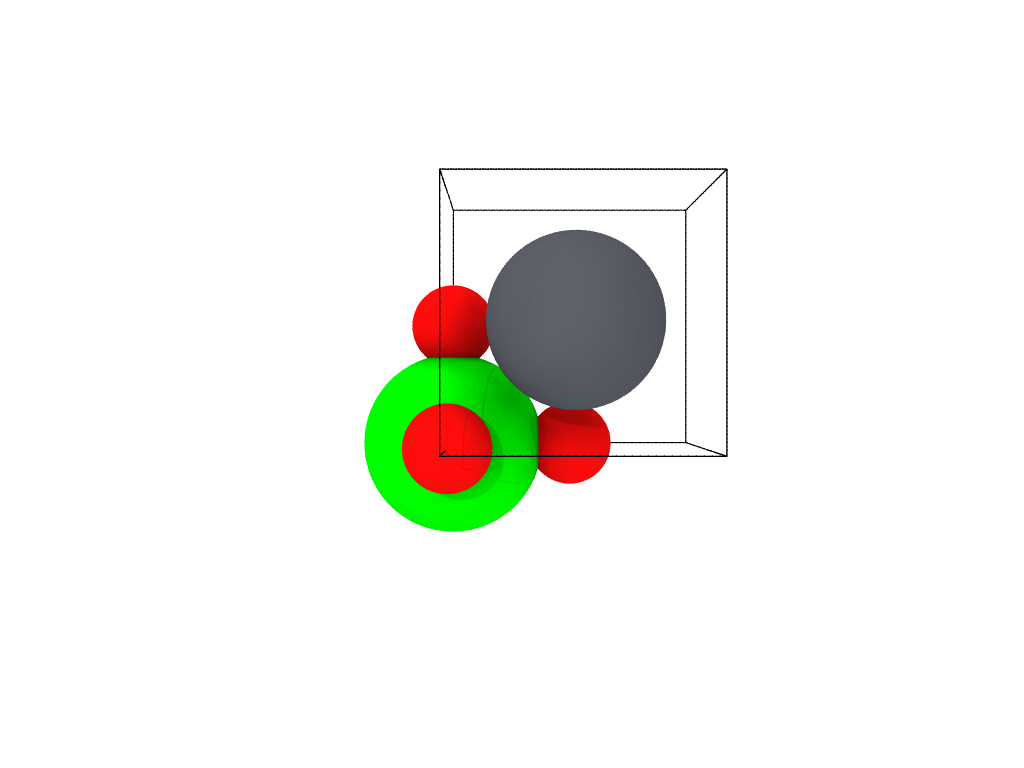

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol, without additional text.
assistant
Pnma
Image:


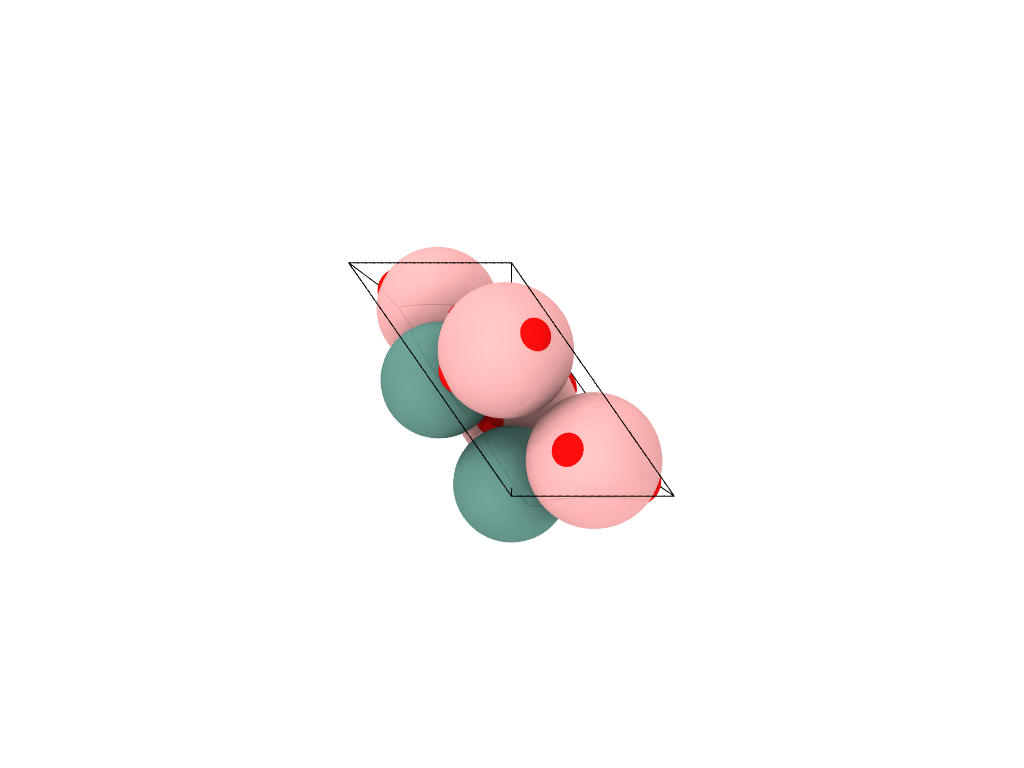

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol, without additional text.
assistant
Pnma
Image:


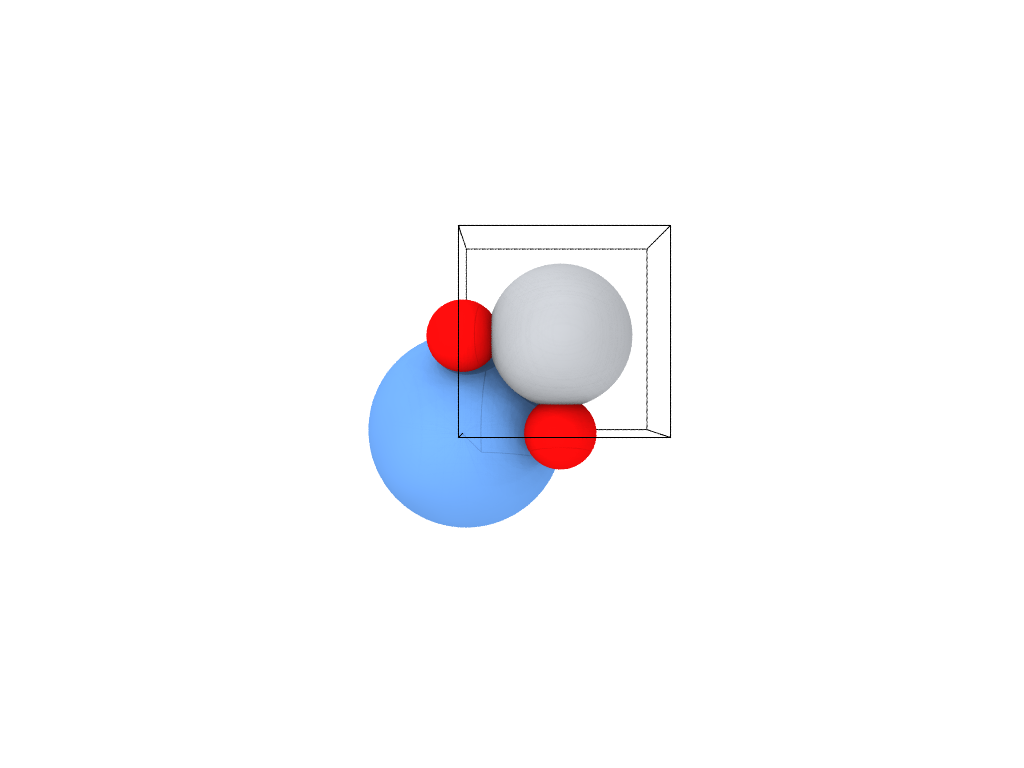

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol, without additional text.
assistant
Pnma
Image:


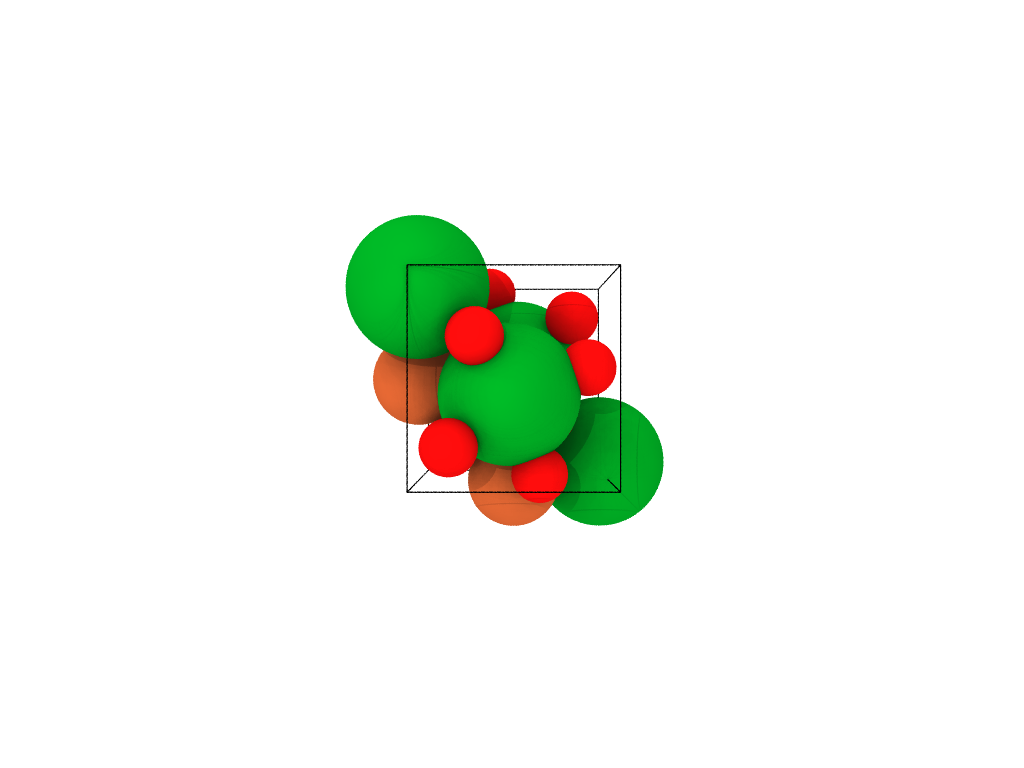

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol, without additional text.
assistant
Pnma


In [ ]:
from IPython.display import display
import PIL.Image

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# TEST_IMAGE: str = "http://images.cocodataset.org/val2017/000000039769.jpg"
TEST_QUESTION: str = "What is the space group of this material? Just answer the space group symbol, without additional text."
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

def test_img_greedy(img_id):

    TEST_IMAGE = os.path.join(IMG_DIR, f"{img_id}.png")

    # Load image
    loaded_img = load_image_from_path(TEST_IMAGE)

    # Display image
    print("Image:")
    display(loaded_img)

    # Prepare messages
    messages = [{"role": "user", "content": [
        {"type": "image", "image": loaded_img},
        {"type": "text", "text": TEST_QUESTION}
    ]}]

    # Encode and generate
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[loaded_img], return_tensors="pt").to(ft_model.device)

    with torch.no_grad():
        out_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

    # Decode output
    output_text = processor.batch_decode(out_ids, skip_special_tokens=True)[0]
    print("Model Output:", output_text)


for img_id in test_cases:
    test_img_greedy(img_id)

| Material ID | Model Output | Ground Truth | Evaluation |
|-------------|--------------|--------------|----------- |
| mp-1068577  | Pnma         | Pm-3m        | Incorrect  |
| mp-1100874  | Pnma         | Pnma         | Correct    |
| mp-865927   | Pnma         | Pm-3m        | Incorrect  |
| mp-22588    | Pnma         | Pnma         | Correct    |

#### **Non-Greedy Decoding**

Due to the imbalance in training set (which favors Pnma group), a non-greedy decoding configuration with temperature slightly higher than 1 (that moderately flattens the distribution) might help correct for bias towards the high-frequency group.

In [36]:
from IPython.display import display
import PIL.Image

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# TEST_IMAGE: str = "http://images.cocodataset.org/val2017/000000039769.jpg"
TEST_QUESTION: str = "What is the space group of this material? Just answer the space group symbol, without additional text."
MAX_NEW_TOKENS: int = 8
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

def test_img(img_id):

    TEST_IMAGE = os.path.join(IMG_DIR, f"{img_id}.png")

    # Load image
    loaded_img = load_image_from_path(TEST_IMAGE)

    # Display image
    print("Image:")
    display(loaded_img)

    # Prepare messages
    messages = [{"role": "user", "content": [
        {"type": "image", "image": loaded_img},
        {"type": "text", "text": TEST_QUESTION}
    ]}]

    # Encode and generate
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[loaded_img], return_tensors="pt").to(ft_model.device)

    # with torch.no_grad():
    #     out_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
    with torch.no_grad():
      out_ids = ft_model.generate(
          **inputs,
          max_new_tokens=MAX_NEW_TOKENS,
          do_sample=True,
          temperature=1.2,
          top_p=0.98
      )

    # Decode output
    output_text = processor.batch_decode(out_ids, skip_special_tokens=True)[0]
    print("Model Output:", output_text)

Image:


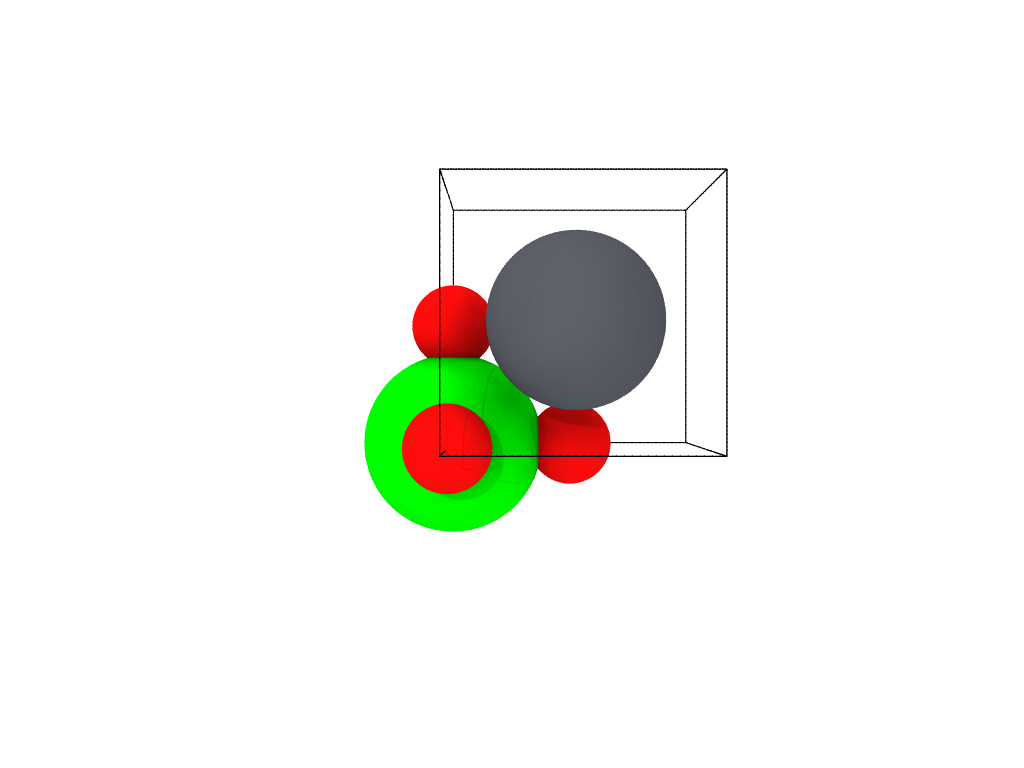

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol, without additional text.
assistant
Pm-3m
Image:


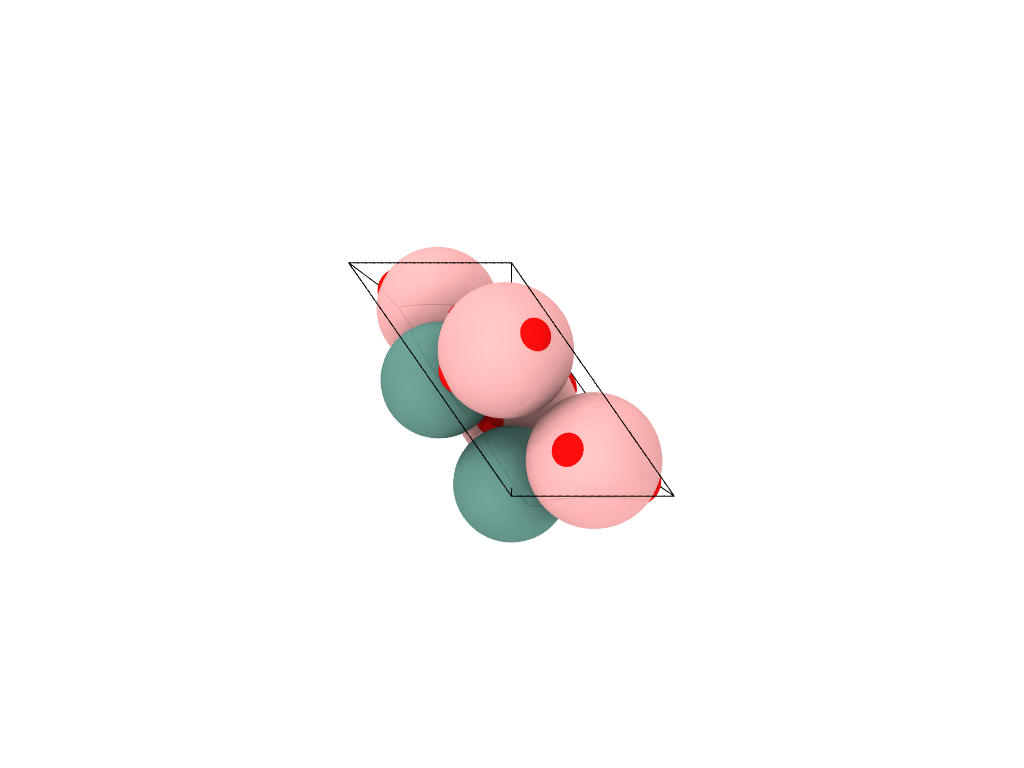

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol, without additional text.
assistant
R-3c
Image:


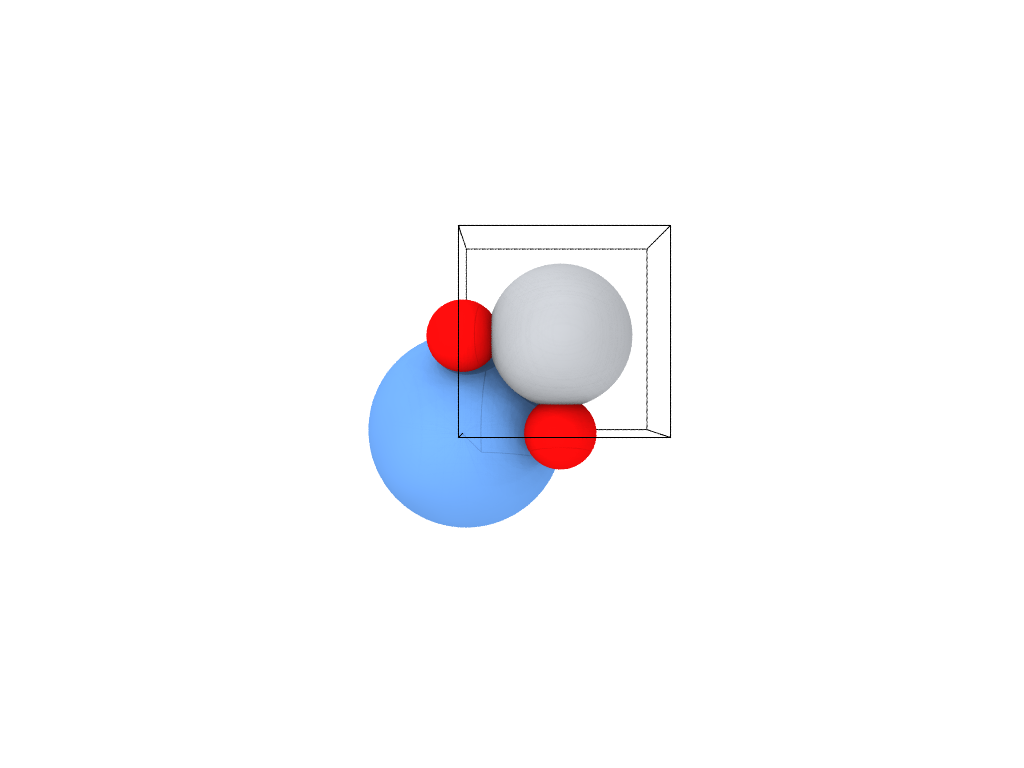

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol, without additional text.
assistant
P4mm
Image:


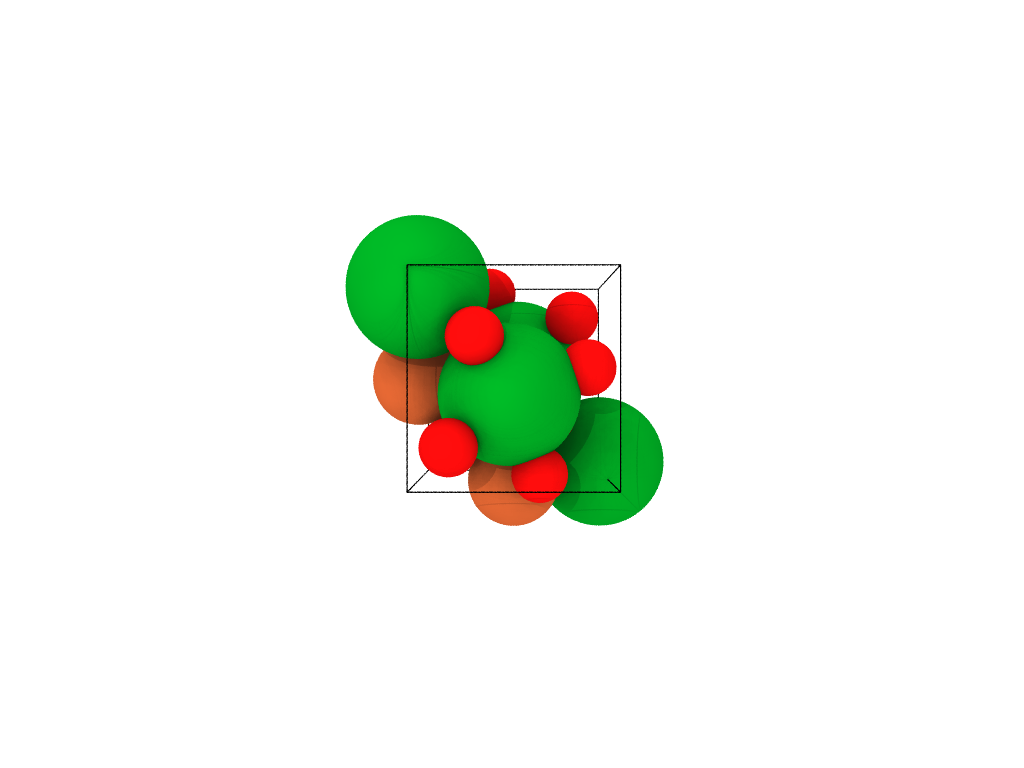

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol, without additional text.
assistant
Pnma


In [37]:
for img_id in test_cases:
    test_img(img_id)

| Material ID | Model Output | Ground Truth | Evaluation |
|-------------|--------------|--------------|----------- |
| mp-1068577  | Pm-3m        | Pm-3m        | Correct    |
| mp-1100874  | R-3c         | Pnma         | Incorrect  |
| mp-865927   | P4mm         | Pm-3m        | Incorrect  |
| mp-22588    | Pnma         | Pnma         | Correct    |

**Provide Options**

Image:


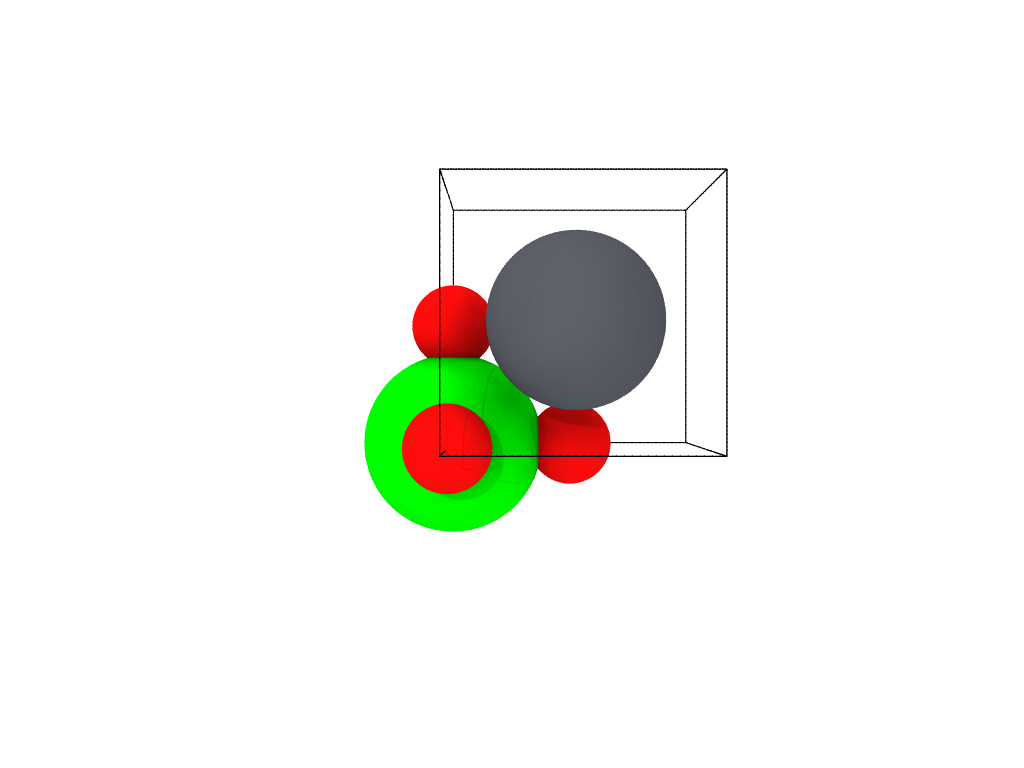

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Potential options include Pnma, Pm-3m, R-3c, I4/mcm, P4mm.Just answer the space group symbol, without additional text.
assistant
Pnma
Image:


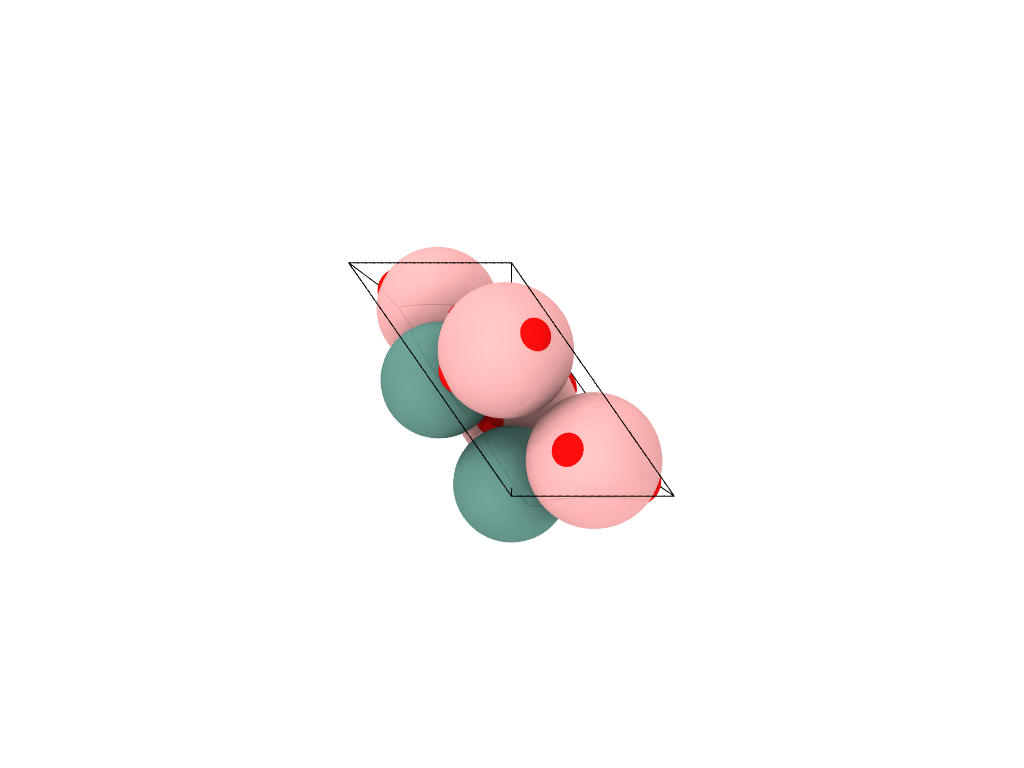

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Potential options include Pnma, Pm-3m, R-3c, I4/mcm, P4mm.Just answer the space group symbol, without additional text.
assistant
Pnma
Image:


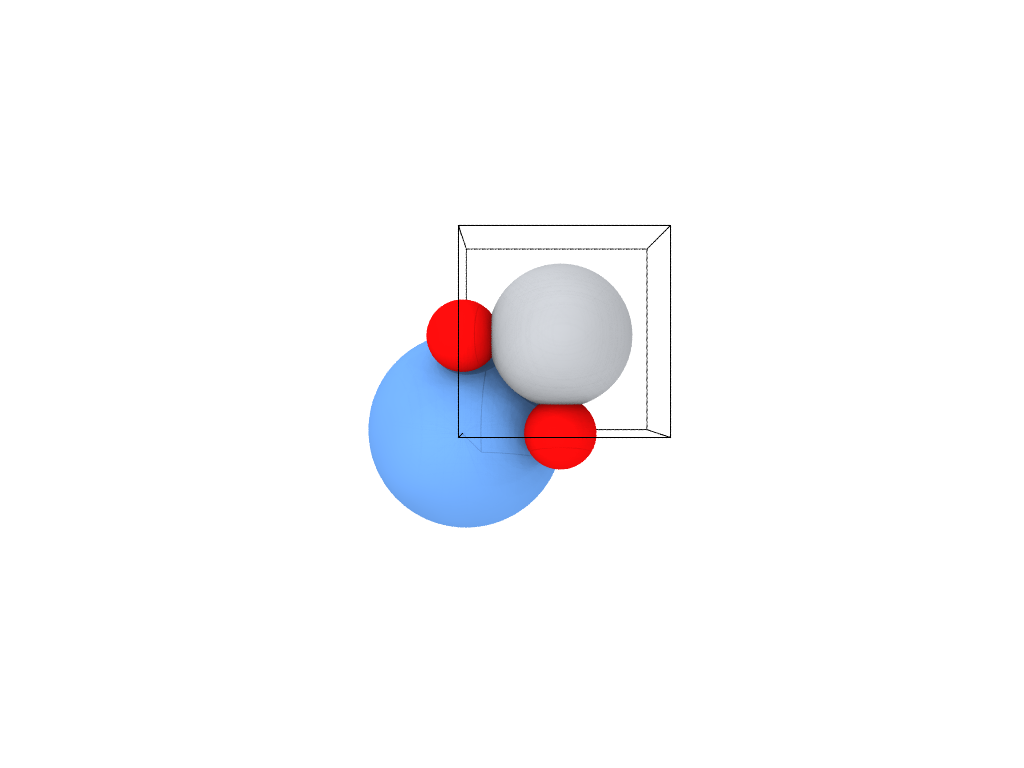

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Potential options include Pnma, Pm-3m, R-3c, I4/mcm, P4mm.Just answer the space group symbol, without additional text.
assistant
Pnma
Image:


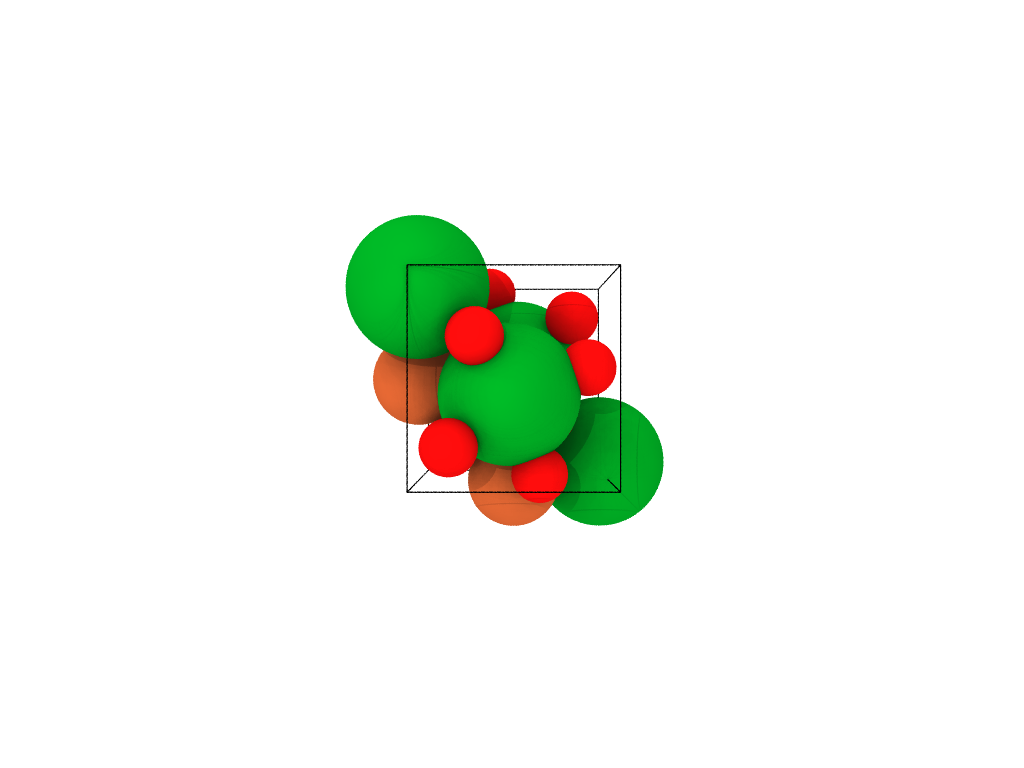

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Potential options include Pnma, Pm-3m, R-3c, I4/mcm, P4mm.Just answer the space group symbol, without additional text.
assistant
Pnma


In [38]:
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# TEST_IMAGE: str = "http://images.cocodataset.org/val2017/000000039769.jpg"
TEST_QUESTION: str = "What is the space group of this material? Potential options include Pnma, Pm-3m, R-3c, I4/mcm, P4mm.Just answer the space group symbol, without additional text."
MAX_NEW_TOKENS: int = 8
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

for img_id in test_cases:
    test_img(img_id)

| Material ID | Model Output | Ground Truth | Evaluation |
|-------------|--------------|--------------|----------- |
| mp-1068577  | Pnma         | Pm-3m        | Incorrect  |
| mp-1100874  | Pnma         | Pnma         | Correct    |
| mp-865927   | Pnma         | Pm-3m        | Incorrect  |
| mp-22588    | Pnma         | Pnma         | Correct    |

### **Further Error Analysis**

**Training Example**

Image:


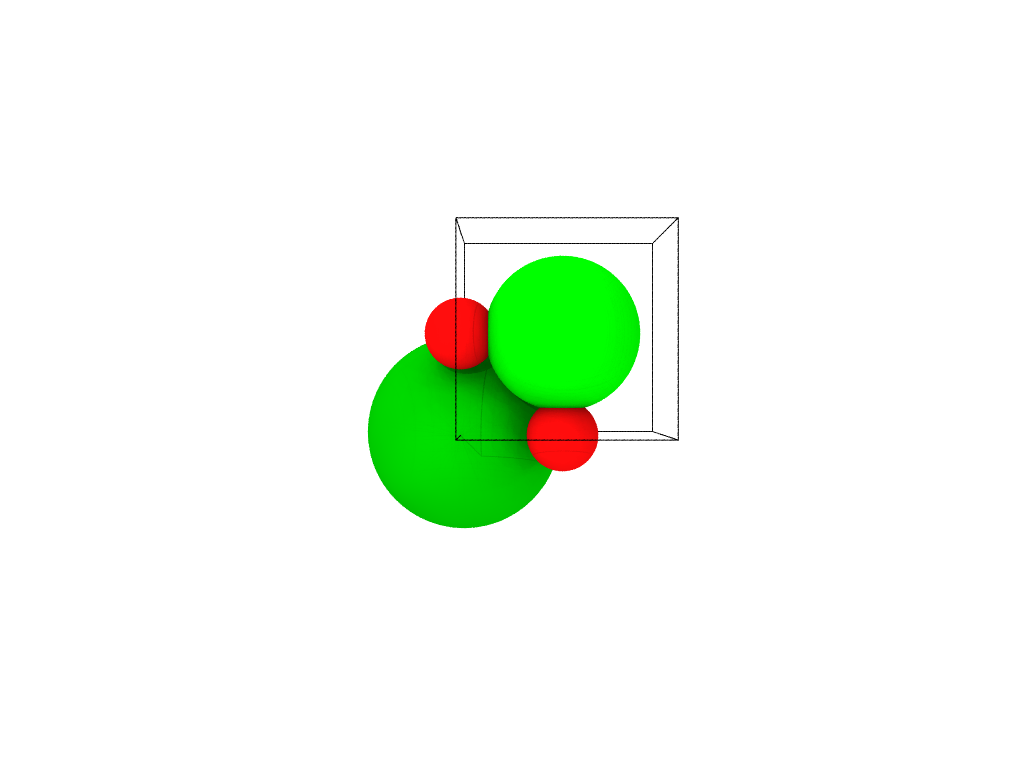

Model Output: system
You are a helpful assistant.
user
What is the space group of this material? Just answer the space group symbol, without additional text.
assistant
Pm-3m


In [12]:
test_img_greedy("mp-3834")

**Label Probabilities for Testing Example**

In [26]:
import torch
import torch.nn.functional as F

labels = ["Pnma", "Pm-3m", "R-3c", "I4/mcm", "P4mm"]

def class_logprobs(img_id, labels):
    TEST_IMAGE = os.path.join(IMG_DIR, f"{img_id}.png")

    # Load image
    loaded_img = load_image_from_path(TEST_IMAGE)

    # Display image
    print("Image:")
    display(loaded_img)

    # Prepare messages
    messages = [{"role": "user", "content": [
        {"type": "image", "image": loaded_img},
        {"type": "text", "text": TEST_QUESTION}
    ]}]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    base_inputs = processor(
        text=[text],
        images=[loaded_img],
        return_tensors="pt"
    ).to(ft_model.device)

    base_len = base_inputs.input_ids.shape[1]
    results = {}

    for label in labels:

        label_ids = processor.tokenizer(label, add_special_tokens=False).input_ids
        label_ids = torch.tensor(label_ids, device=ft_model.device).unsqueeze(0)

        input_ids = torch.cat([base_inputs.input_ids, label_ids], dim=1)

        with torch.no_grad():
            outputs = ft_model(
                input_ids=input_ids,
                attention_mask=torch.ones_like(input_ids),
                pixel_values=base_inputs.pixel_values,
                image_grid_thw=base_inputs.image_grid_thw,   # critical fix
            )

        logits = outputs.logits

        logprob = 0.0
        for i, tok in enumerate(label_ids[0]):
            step_logits = logits[0, base_len + i - 1]
            logprob += F.log_softmax(step_logits, dim=-1)[tok]

        results[label] = logprob.item()

    return results

Image:


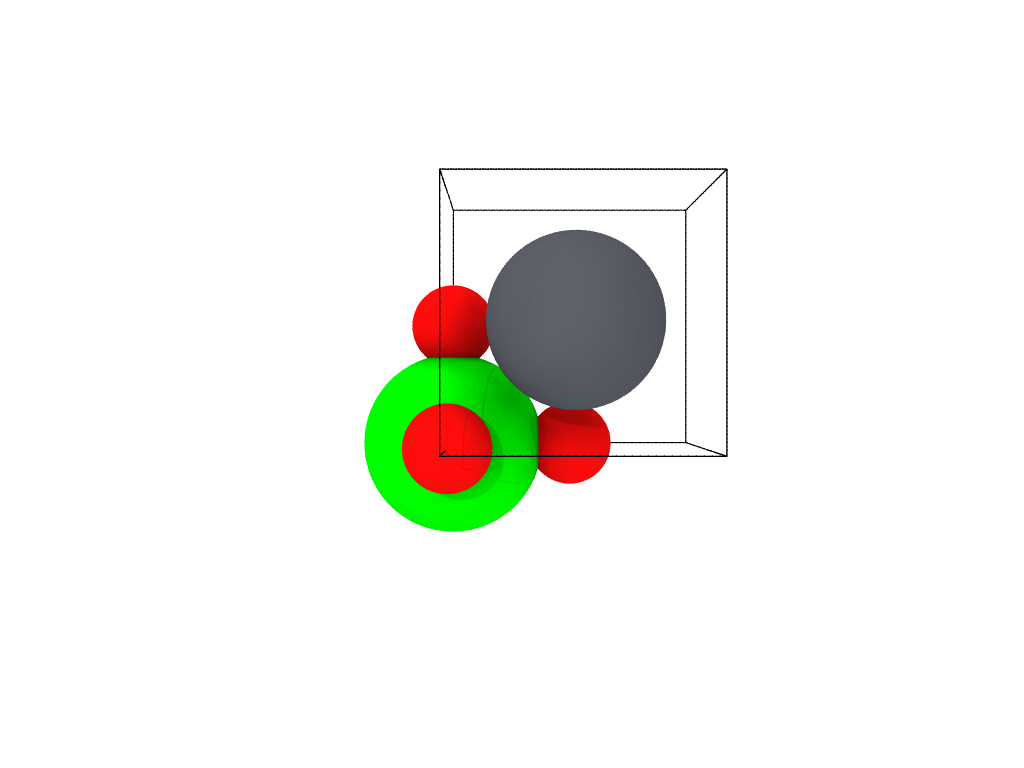

Pnma -0.55224609375
Pm-3m -1.1298828125
R-3c -3.32421875
I4/mcm -5.99609375
P4mm -3.06640625
Pnma 0.5851323008537292
Pm-3m 0.3283897936344147
R-3c 0.03659330680966377
I4/mcm 0.002529420657083392
P4mm 0.04735525697469711


In [28]:
scores = class_logprobs("mp-1068577", labels)

for k, v in scores.items():
    print(k, v)



vals = torch.tensor(list(scores.values()))
probs = torch.softmax(vals, dim=0)

for k,p in zip(scores.keys(), probs):
    print(k, p.item())

## Questions to answer:

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.

The results from finetuned model using different questions are compared with the corresponding results with the pretrained model.

**Question Phrasing A (Provide no options)**

Pre-trained: Greedy Decoding

| Material ID | Model Output | Ground Truth | Evaluation |
|-------------|--------------|--------------|----------- |
| mp-1068577  | P42/mc       | Pm-3m        | Incorrect  |
| mp-1100874  | P43n2        | Pnma         | Incorrect  |
| mp-865927   | P42/mc       | Pm-3m        | Incorrect  |
| mp-22588    | P63/mmc      | Pnma         | Incorrect  |

Fine-tuned: Greedy Decoding

| Material ID | Model Output | Ground Truth | Evaluation |
|-------------|--------------|--------------|----------- |
| mp-1068577  | Pnma         | Pm-3m        | Incorrect  |
| mp-1100874  | Pnma         | Pnma         | Correct    |
| mp-865927   | Pnma         | Pm-3m        | Incorrect  |
| mp-22588    | Pnma         | Pnma         | Correct    |


Fine-tuned: Non-Greedy Decoding (`temp=1.15`)

| Material ID | Model Output | Ground Truth | Evaluation |
|-------------|--------------|--------------|----------- |
| mp-1068577  | Pm-3m        | Pm-3m        | Correct    |
| mp-1100874  | R-3c         | Pnma         | Incorrect  |
| mp-865927   | P4mm         | Pm-3m        | Incorrect  |
| mp-22588    | Pnma         | Pnma         | Correct    |


**Question Phrasing B (Provide options)**

Pre-trained

| Material ID | Model Output | Ground Truth | Evaluation |
|-------------|--------------|--------------|----------- |
| mp-1068577  | P4mm         | Pm-3m        | Incorrect  |
| mp-1100874  | P4mm         | Pnma         | Incorrect  |
| mp-865927   | P4mm         | Pm-3m        | Incorrect  |
| mp-22588    | P4mm         | Pnma         | Incorrect  |

Fine-tuned: Non-Greedy Decoding (`temp=1.15`)

| Material ID | Model Output | Ground Truth | Evaluation |
|-------------|--------------|--------------|----------- |
| mp-1068577  | Pnma         | Pm-3m        | Incorrect  |
| mp-1100874  | Pnma         | Pnma         | Correct    |
| mp-865927   | Pnma         | Pm-3m        | Incorrect  |
| mp-22588    | Pnma         | Pnma         | Correct    |

**Improvement & Question Phrasing**

It is observed that LoRA finetuning has effectively improved accuracy when the question phrasing doesn't included options, as the pretrained model generates random space group symbols not associated with the materials of interest. When using greedy decoding for the fine-tuned model, the model strongly favors Pnma, which has the highest frequency in the dataset. When using non-greedy decoding, the fine-tuned model is more flexible and can generate correct answers for both Pnma and non-Pnma cases.

Improvement is also oberved for question phrasing that includes potential options. However, in this case, even when using a non-greedy decoding approach with temperature>1, the fine-tuned model still highly favors Pnma.

**LoRA Fine-tuning Effects**

By examining fine-tuned models on training samples, it is observed that the model can output correct answers for minority space groups, indicating the model has successfully learnt to ingest some visual features for the task, instead of solely relying on language priors.

Meanwhile, the logits and probabilities computation of different space group labels on an unseen test example (true label Pm-3m) show the following:

|Group  | Prob  |
|-------|-------|
|Pnma   |0.5851 |
|Pm-3m  |0.3283 |
|R-3c   |0.0365 |
|I4/mcm |0.0025 |
|P4mm   |0.0473 |

It indicates that the imbalanced training set has led to bias favoring the highest-frequency group (Pnma), but the fine-tuning still learnt to ingest visual features, attributing probabilities of comparable magnitude to the true label as well.
The results also indicate that the errors of pretrained models resulting from randomly generating space groups have been largely eliminated, and the model has learnt to meaningfully process the domain-specific images for the task.


**New Errors and Biases**

In many cases, it is observed that the fine-tuned model highly favors the Pnma group as an answer, which is a bias introduced by the fine-tuning process.

The dataset is imbalanced, with Pnma being the highest-frequency group and accounting for around 1/3 of the entire dataset. Due to the small dataset size, it's impossible to have hundreds to thousands of examples for any class, which will lead to better performance post fine-tuning. And because the least-frequent group accounts for only 5\% of the original dataset, reducing imbalance would lead to an even smaller training set, and compromise fine-tuning effectivenss.

With the current data, procedure, and resulting models, it's more promising to use non-greedy decoding (with temperature>1) post fine-tuning to correct for the biases favoring Pnma.

# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?
2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?

**What concept did you find the most interesting?**

The concept of prompt engineering feels the most interesting to me. Given that there are different parts of natural language prompts (e.g. question phrasing vs. system prompt) and different ways to modify them, it offers a lot of flexibilities to tailor the model behaviors for specific tasks, without doing complicated data curation and fine-tuning. But for highly domain-specific data and tasks, ways to improve general pre-trained foundation models with prompt engineering seem highly underexplored.

**Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.**

LoRA fine-tuning would be a potentially useful method towards material design or other generative tasks with our dataset. Though previously focusing on graphs and text modalities, exploring the use of images generated from the structure files in this assignment seems to have better results than what I expected. With further data augmentation through unit cell images of different orientations, the multimodall LM might actually be able to serve as a useful agent for tasks that require natural-language-formatted responses.

**Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?**

The uses of prefix tuning and adaptors to help language models ingest non-text modalities seem to be highly important and interesting. It would be nice if the homework could be designed to cover some of its internal workings and how fine-tuning on images from new domains changes the adaptor behavior and visual token embeddings.

Due to the limitations and nature of our dataset, I explored a bit of non-greedy decoding in the homework by myself. It would be nice if the homework provides more guidance and explanations on the best practice.